# F1 — Seasons (1950–2024)

Season-level analyses across the full history of F1.
This notebook covers **Section 5** of `QuestionsF1.txt`.

## Questions covered
| # | Question |
|---|---|
| 5.1  | Maximum possible points each season (per year) |
| 5.2  | Average number of races per year (year-by-year time series) |
| 5.2a | Average number of races per season, by era |
| 5.2b | Average number of races per season, by decade |
| 5.3  | Closest championship battles (smallest gap champion ↔ runner-up) — raw points + % of season max |
| 5.3c | Closest battles by gap **entering the final round** — captures last-race-decided titles (e.g. 2021) |
| 5.4  | Biggest championship blowouts (largest gap) |
| 5.5  | Seasons with the most different race winners — raw count |
| 5.5b | Distinct-winners ratio across all seasons (era-fair) |
| 5.5c | Most dominant seasons + drivers-vs-teams winner comparison |
| 5.5d | Competitiveness by era (avg driver + team ratios) |
| 5.6  | Seasons where champion had fewer wins than the runner-up |

The scoring system has changed several times since 1950, so all "points" comparisons should be read with that in mind. Where useful, we normalize (e.g. **gap as % of available points** in 5.3 / 5.4 — see the 5.3 explainer).

## Setup — imports, data loading, Indy cleanup


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from f1_utils import (
    show_and_save, eras_df, year_to_era, apply_default_style,
)
apply_default_style()

sns.set_theme(style='whitegrid')

drivers      = pd.read_csv('excel/drivers.csv')
results      = pd.read_csv('excel/results.csv')
races        = pd.read_csv('excel/races.csv')
constructors = pd.read_csv('excel/constructors.csv')
standings    = pd.read_csv('excel/driver_standings.csv')

drivers['driver'] = drivers['surname'] + ' ' + drivers['forename'].str[0] + '.'

# Indy cleanup — drop the 1950–60 American oval race that pollutes per-driver stats
indy_race_ids = races.loc[
    races['name'].str.contains('Indianapolis', case=False, na=False), 'raceId']

results   = results  [~results  ['raceId'].isin(indy_race_ids)].copy()
races     = races    [~races    ['raceId'].isin(indy_race_ids)].copy()
standings = standings[~standings['raceId'].isin(indy_race_ids)].copy()

os.makedirs('charts', exist_ok=True)

def show_and_save(filename, dpi=150):
    plt.savefig(f'charts/{filename}', dpi=dpi, bbox_inches='tight')
    plt.show()


DECADE_COLORS = {
    1950: '#8B2635', 1960: '#D2691E', 1970: '#DAA520', 1980: '#2E8B57',
    1990: '#0E7C7B', 2000: '#1F4E79', 2010: '#5B2A86', 2020: '#3A3A3A',
}

# F1 era reference table — same one defined in 'Statistics for each Era.ipynb'.
# Used in 5.2a (per-era averages) and any other era-aware aggregation.
eras = [
    (1, 'Pre-aerodynamic / Front-engine',   1950, 1958),
    (2, 'Rear-engine revolution',           1959, 1967),
    (3, 'Wings & aerodynamics',             1968, 1982),
    (4, 'Turbo era',                        1983, 1988),
    (5, 'Active suspension / post-turbo',   1989, 1993),
    (6, 'Driver-aid ban / pre-V10',         1994, 1999),
    (7, 'V10 era (Ferrari/Schumacher)',     2000, 2005),
    (8, 'V8 era',                           2006, 2013),
    (9, 'Hybrid V6 turbo',                  2014, 2025),
]
eras_df = pd.DataFrame(eras, columns=['era_id', 'name_en', 'year_start', 'year_end'])

# Cross-era color palette — distinct enough to read on a small-multiples chart
ERA_COLORS = {
    1: '#8B2635', 2: '#D2691E', 3: '#DAA520', 4: '#2E8B57', 5: '#0E7C7B',
    6: '#1F4E79', 7: '#5B2A86', 8: '#3A3A3A', 9: '#B0306B',
}

def year_to_era(year):
    """Map a 4-digit year to its era_id (or None if outside 1950–2025)."""
    hit = eras_df[(eras_df['year_start'] <= year) & (year <= eras_df['year_end'])]
    return int(hit['era_id'].iloc[0]) if len(hit) else None


# Last race of each season (for year-end snapshots)
last_race_per_year = (
    races.assign(date=lambda d: pd.to_datetime(d['date']))
    .sort_values('date').groupby('year').last()
    .reset_index()[['year', 'raceId']]
    .rename(columns={'raceId': 'final_raceId'})
)

# Year-end final standings (used by 5.3, 5.4, 5.6).
# After the merge, `year` comes from last_race_per_year — already the season's
# year — so no second merge with `races` is needed (would collide on `year`).
final_standings = (
    standings.merge(last_race_per_year, left_on='raceId', right_on='final_raceId')
    [['year', 'driverId', 'position', 'points', 'wins']]
)

print(f'Seasons      : {races["year"].nunique()}')
print(f'Race rows    : {len(races):,}')
print(f'Result rows  : {len(results):,}')
print(f'Standings rows: {len(standings):,}')
print(f'Eras loaded  : {len(eras_df)}')


Seasons      : 75
Race rows    : 1,114
Result rows  : 26,354
Standings rows: 34,194
Eras loaded  : 9


---
### Chart 5.1 — Maximum possible points each season

For each year, "max possible points" = the points a driver would have if they won every race AND scored every available bonus (e.g., fastest lap point in 2019+).

Computed empirically from the data: per race, take `MAX(points)` across all drivers (= the highest score *anyone* could have got); sum that across the season.

This makes the **scoring system reform** very visible: the early V10 era (~1991) bumps the per-win value from 9 → 10, the 2010 reform jumps to 25, and 2019 adds the fastest-lap bonus.


Max possible points per season (head + tail):
 year  max_possible  races  per_race_max
 1950         52.00      6           9.0
 1951         55.00      7           9.0
 1952         62.50      7           9.0
 1953         67.50      8           9.0
 1954         66.14      8           9.0
 1955         51.00      6           9.0
 1956         56.00      7           9.0
 1957         57.00      7           9.0
 1958         83.00     10           9.0
 1959         67.00      8           9.0
...
 year  max_possible  races  per_race_max
 2015         475.0     19          25.0
 2016         525.0     21          25.0
 2017         500.0     20          25.0
 2018         525.0     21          25.0
 2019         532.0     21          26.0
 2020         430.0     17          26.0
 2021         543.5     22          26.0
 2022         557.0     22          26.0
 2023         558.0     22          26.0
 2024         604.0     24          26.0


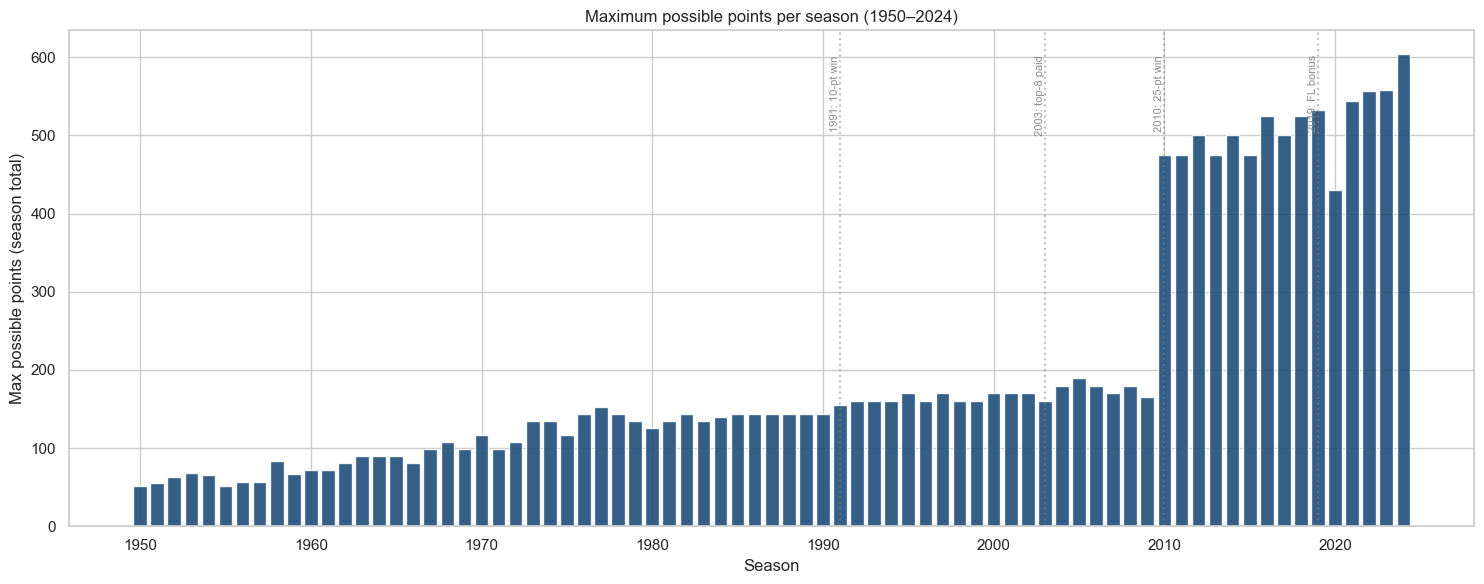

In [50]:
# Per race, max single-race score awarded to any driver
race_max = (results.groupby('raceId')['points'].max()
            .reset_index(name='max_per_race'))

season_max = (
    race_max.merge(races[['raceId', 'year']], on='raceId')
    .groupby('year')
    .agg(max_possible=('max_per_race', 'sum'),
         races=('raceId', 'count'),
         per_race_max=('max_per_race', 'max'))
    .reset_index()
)

print('Max possible points per season (head + tail):')
print(season_max.head(10).to_string(index=False))
print('...')
print(season_max.tail(10).to_string(index=False))


# Plot: max_possible per year as a single-axis bar chart.
# Per-race max is still computed (above) and remains visible in the table —
# we just don't draw it as a competing line on the chart anymore.
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(season_max['year'], season_max['max_possible'],
       color='#1F4E79', edgecolor='white', alpha=0.9,
       label='Season total (sum of per-race maxes)')
ax.set_xlabel('Season')
ax.set_ylabel('Max possible points (season total)')

# Annotate notable scoring-system changes — vertical dotted lines + side label
for x, txt in [(1991, '1991: 10-pt win'),
               (2003, '2003: top-8 paid'),
               (2010, '2010: 25-pt win'),
               (2019, '2019: FL bonus')]:
    if season_max['year'].min() <= x <= season_max['year'].max():
        ax.axvline(x, color='gray', linestyle=':', alpha=0.5)
        ax.text(x, ax.get_ylim()[1] * 0.95, txt,
                rotation=90, ha='right', va='top',
                fontsize=8, color='gray', alpha=0.9)

ax.set_title('Maximum possible points per season (1950–2024)')
fig.tight_layout()
show_and_save('5.1_max_possible_points.png')


**SQL equivalent**
```sql
-- 5.1: Max possible points per season (sum of MAX points awarded per race)
WITH race_max AS (
    SELECT  r.raceId, MAX(r.points) AS max_per_race
    FROM    results r
    JOIN    races   ra ON r.raceId = ra.raceId
    WHERE   ra.name NOT LIKE '%Indianapolis%'
    GROUP   BY r.raceId
)
SELECT  ra.year, SUM(rm.max_per_race) AS max_possible, COUNT(*) AS races
FROM    race_max rm
JOIN    races    ra ON rm.raceId = ra.raceId
GROUP   BY ra.year
ORDER   BY ra.year;
```


---
### Chart 5.2 — Average number of races per year (with trend)

Simple time series: races per season, plus the average per decade as a comparison line.

The trend is monotonically increasing — early seasons had 6–10 races, modern seasons have 22–24. This matters for almost every other comparison in the project: a "100 wins" total compresses very different career lengths.


Mean races per year over all of F1 history: 14.9

Average per decade:
 decade  avg_per_decade
   1950             7.4
   1960             9.9
   1970            14.4
   1980            15.6
   1990            16.2
   2000            17.4
   2010            19.8
   2020            21.4


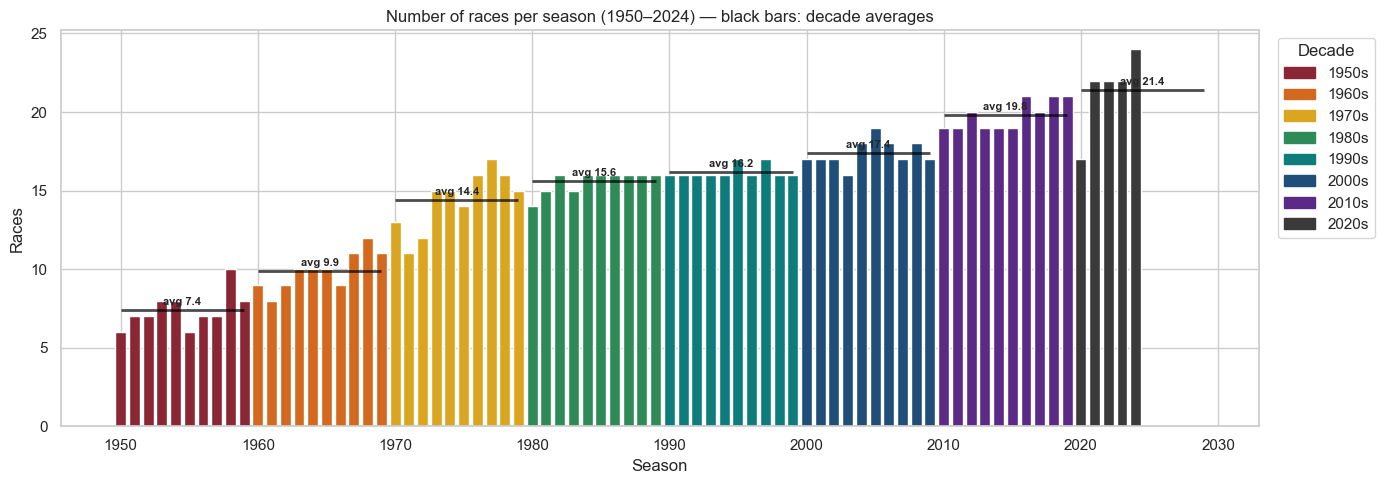

In [51]:
races_per_year = (races.groupby('year').size()
                  .reset_index(name='races'))

races_per_year['decade'] = (races_per_year['year'] // 10) * 10
decade_avg = (races_per_year.groupby('decade')['races'].mean()
              .reset_index(name='avg_per_decade'))

print(f'Mean races per year over all of F1 history: {races_per_year["races"].mean():.1f}')
print()
print('Average per decade:')
print(decade_avg.to_string(index=False))


fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = [DECADE_COLORS[d] for d in races_per_year['decade']]
ax.bar(races_per_year['year'], races_per_year['races'],
       color=bar_colors, edgecolor='white')

# Decade-average step line
for d, avg in zip(decade_avg['decade'], decade_avg['avg_per_decade']):
    ax.hlines(avg, d, d + 9, color='black', linewidth=2, alpha=0.7)
    ax.text(d + 4.5, avg + 0.3, f'avg {avg:.1f}', ha='center',
            fontsize=8, fontweight='bold')

used = sorted(races_per_year['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
ax.legend(handles=handles, title='Decade', loc='upper left',
          bbox_to_anchor=(1.01, 1.0), frameon=True)

ax.set_title('Number of races per season (1950–2024) — black bars: decade averages')
ax.set_xlabel('Season')
ax.set_ylabel('Races')
plt.tight_layout()
show_and_save('5.2_races_per_year.png')


**SQL equivalent**
```sql
-- 5.2: Races per season + per-decade average
WITH per_year AS (
    SELECT  year, COUNT(*) AS races
    FROM    races
    WHERE   name NOT LIKE '%Indianapolis%'
    GROUP   BY year
)
SELECT  (year/10)*10 AS decade, AVG(races) AS avg_races_per_year
FROM    per_year
GROUP   BY (year/10)*10
ORDER   BY decade;
```


---
### Chart 5.2a — Average races per season, by era

5.2 shows year-by-year noise; this view smooths it out by aggregating into the **engine/regulation eras** defined in `eras_df`. Comparing the per-era *average* rather than the total makes long eras and short eras directly comparable. The Hybrid V6 era is the most race-dense in F1 history; the front-engine era was less than a third of that.


Average races per season, by era:
 era_id                        name_en  year_first  year_last  seasons  avg_races  total_races
      1 Pre-aerodynamic / Front-engine        1950       1958        9        7.3           66
      2         Rear-engine revolution        1959       1967        9        9.3           84
      3           Wings & aerodynamics        1968       1982       15       14.1          212
      4                      Turbo era        1983       1988        6       15.8           95
      5 Active suspension / post-turbo        1989       1993        5       16.0           80
      6       Driver-aid ban / pre-V10        1994       1999        6       16.3           98
      7   V10 era (Ferrari/Schumacher)        2000       2005        6       17.3          104
      8                         V8 era        2006       2013        8       18.4          147
      9                Hybrid V6 turbo        2014       2024       11       20.7          228


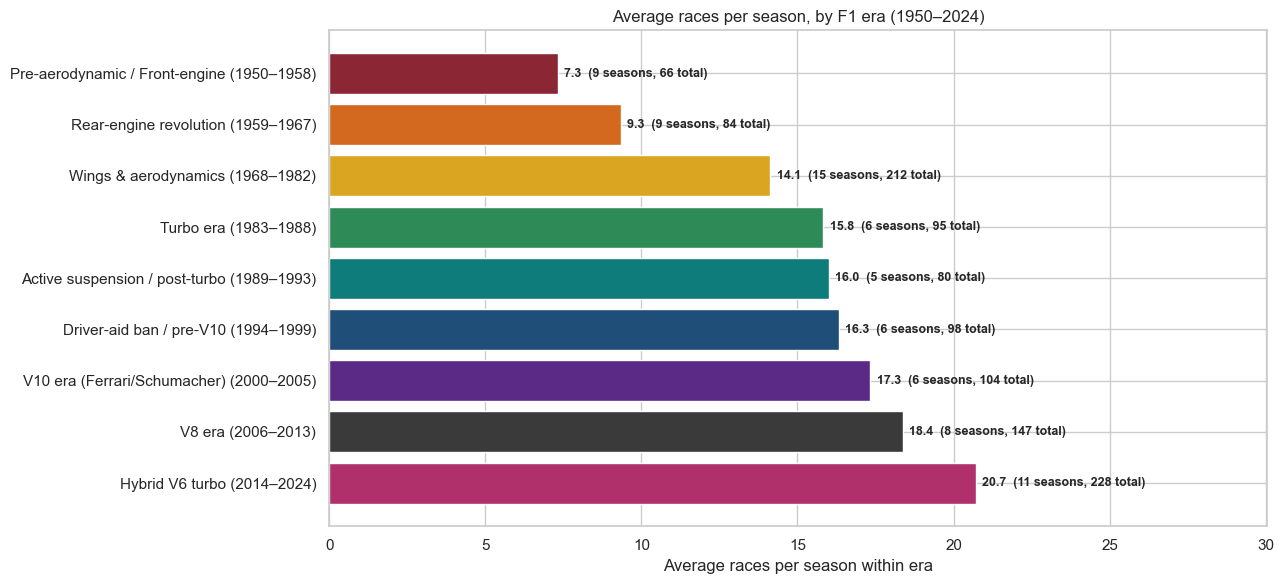

In [52]:
# races_per_year is built in 5.2 — recompute here so this cell can run standalone
races_per_year = (races.groupby('year').size()
                  .reset_index(name='races'))
races_per_year['era_id'] = races_per_year['year'].apply(year_to_era)

# Drop years outside 1950–2025 (shouldn't happen with this dataset, but defensive)
races_per_year_era = races_per_year.dropna(subset=['era_id']).copy()
races_per_year_era['era_id'] = races_per_year_era['era_id'].astype(int)

era_avg = (races_per_year_era
           .groupby('era_id')
           .agg(avg_races=('races', 'mean'),
                seasons=('year', 'count'),
                total_races=('races', 'sum'),
                year_first=('year', 'min'),
                year_last=('year', 'max'))
           .reset_index()
           .merge(eras_df[['era_id', 'name_en']], on='era_id')
           .sort_values('era_id'))

print('Average races per season, by era:')
print(era_avg[['era_id', 'name_en', 'year_first', 'year_last',
               'seasons', 'avg_races', 'total_races']]
      .round({'avg_races': 1})
      .to_string(index=False))


# Horizontal bars — eras chronologically top→bottom (era 1 at top)
fig, ax = plt.subplots(figsize=(13, 6))
era_avg_plot = era_avg.sort_values('era_id', ascending=False)  # reversed for barh
bar_colors = [ERA_COLORS[e] for e in era_avg_plot['era_id']]
y = range(len(era_avg_plot))
ax.barh(y, era_avg_plot['avg_races'], color=bar_colors, edgecolor='white')
labels = (era_avg_plot['name_en']
          + ' ('
          + era_avg_plot['year_first'].astype(str) + '–'
          + era_avg_plot['year_last'].astype(str) + ')')
ax.set_yticks(list(y))
ax.set_yticklabels(labels)

# Label each bar with: avg races (N seasons, T total)
for i, row in enumerate(era_avg_plot.itertuples()):
    ax.text(row.avg_races + 0.2, i,
            f'{row.avg_races:.1f}  ({row.seasons} seasons, {row.total_races} total)',
            va='center', fontsize=9, fontweight='bold')

ax.set_title('Average races per season, by F1 era (1950–2024)')
ax.set_xlabel('Average races per season within era')
ax.set_xlim(0, era_avg_plot['avg_races'].max() * 1.45)
plt.tight_layout()
show_and_save('5.2a_avg_races_by_era.png')


---
### Chart 5.2b — Average races per season, by decade

Same idea as 5.2a but with decade buckets (1950s, 60s, 70s, …) instead of regulatory eras. Decades are a simpler mental model — useful when you don't want to think about V10 vs V8 distinctions. The 2020s show up shorter than the others (5 seasons) and COVID-affected, so read with that caveat.


Average races per season, by decade:
 decade  avg_races  seasons  total_races  year_first  year_last
   1950        7.4       10           74        1950       1959
   1960        9.9       10           99        1960       1969
   1970       14.4       10          144        1970       1979
   1980       15.6       10          156        1980       1989
   1990       16.2       10          162        1990       1999
   2000       17.4       10          174        2000       2009
   2010       19.8       10          198        2010       2019
   2020       21.4        5          107        2020       2024


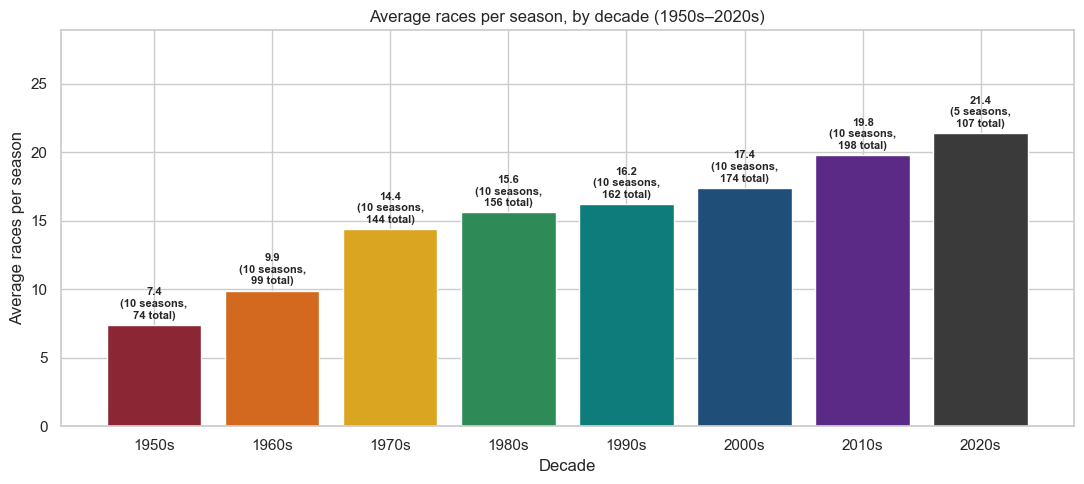

In [53]:
races_per_year['decade'] = (races_per_year['year'] // 10) * 10

decade_avg = (races_per_year
              .groupby('decade')
              .agg(avg_races=('races', 'mean'),
                   seasons=('year', 'count'),
                   total_races=('races', 'sum'),
                   year_first=('year', 'min'),
                   year_last=('year', 'max'))
              .reset_index())

print('Average races per season, by decade:')
print(decade_avg.round({'avg_races': 1}).to_string(index=False))


fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [DECADE_COLORS[d] for d in decade_avg['decade']]
ax.bar(decade_avg['decade'].astype(str) + 's',
       decade_avg['avg_races'],
       color=bar_colors, edgecolor='white')

# Label each bar: avg (N seasons, T total)
for i, row in enumerate(decade_avg.itertuples()):
    ax.text(i, row.avg_races + 0.3,
            f'{row.avg_races:.1f}\n({row.seasons} seasons,\n{row.total_races} total)',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Average races per season, by decade (1950s–2020s)')
ax.set_xlabel('Decade')
ax.set_ylabel('Average races per season')
ax.set_ylim(0, decade_avg['avg_races'].max() * 1.35)
plt.tight_layout()
show_and_save('5.2b_avg_races_by_decade.png')


---
### Chart 5.3 — Closest championship battles (smallest gap champion ↔ runner-up)

Per season, gap = `champion_points − runner_up_points`. We then show this gap **two ways**, because raw points and percentage tell very different stories.

#### What "raw points" means
The plain difference in points at season-end. Easy to read off the record books, but **not comparable across eras** — the scoring system has changed several times:

| Period | Points for a win | A 30-point gap means… |
|---|---|---|
| 1950–1959 | 8 (later 9) | ~3–4 races' difference |
| 1991–2009 | 10 | 3 races' difference |
| 2010–today | 25 | ~1 race's difference |

So when "raw points" puts the top-10 closest titles list, modern seasons look artificially closer in raw terms simply because each race contributes more points. The reverse is also true: blowouts (5.4) look extreme in modern raw points but may have been historically routine.

#### What "% of season max points" means
`gap ÷ max_possible_points_for_that_season × 100`. The denominator comes from chart 5.1 — the total points available across the whole season if a driver won everything.

Worked example:
- **1965**: 9-pt wins, ~10 races/season → max ≈ 90 pts. A 30-pt gap = **33 %** — that's a blowout.
- **2010**: 25-pt wins, ~19 races/season → max ≈ 475 pts. A 30-pt gap = **6.3 %** — that's a nail-biter.

Same 30 points, completely different story. The % version puts every season on a common scale, so the closeness of a 1958 title chase can be compared directly with 2008. **This is the one to look at if you want to know "how close was it, really?"**

#### Why the two top-10 lists rarely overlap
Raw-points closeness skews modern (low-points-per-win inflates the look of "close"); %-of-max skews historical and produces the genuinely closest seasons across all of F1.

#### Recommendations (data-analyst lens)
- **Treat % as the headline metric**, raw as a footnote — same logic any motorsport historian would use.
- **Add "gap in wins"** as a complementary view. A win is era-stable: it's been a single Sunday victory since 1950. "Vettel won 2012 by 3 points (0 wins differential)" tells you something the raw and % views miss.
- **Add "gap entering the final round"** (Chart 5.3c). The season-end gap miscounts titles that were decided on the last day — 2021 (Verstappen vs Hamilton) ranks **#29 by raw gap** and **#16 by % of season max**, even though the two drivers were tied on points going into Abu Dhabi. A penultimate-race snapshot is the only way to surface that.
- **Watch out for seasons with abnormal points systems** (e.g. 2014 had a double-points finale). They distort both gaps; flag them in the table rather than silently letting them rank.
- **For storytelling**, the *most* useful version is probably "% of max" *plus* the win count — combined, they answer "was the title decided on speed or on consistency?"

TOP 10 — Closest championship battles by raw points gap:
 year     driver_p1  points_p1    driver_p2  points_p2  gap
 1984      Lauda N.       72.0     Prost A.       71.5  0.5
 1958   Hawthorn M.       42.0      Moss S.       41.0  1.0
 1961       Hill P.       34.0 von Trips W.       33.0  1.0
 1964    Surtees J.       40.0      Hill G.       39.0  1.0
 1976       Hunt J.       69.0     Lauda N.       68.0  1.0
 1981     Piquet N.       50.0 Reutemann C.       49.0  1.0
 1994 Schumacher M.       92.0      Hill D.       91.0  1.0
 2007  Räikkönen K.      110.0  Hamilton L.      109.0  1.0
 2008   Hamilton L.       98.0     Massa F.       97.0  1.0
 1983     Piquet N.       59.0     Prost A.       57.0  2.0

TOP 10 — Closest by % of season-max points:
 year     driver_p1    driver_p2  points_p1  points_p2  gap  gap_pct
 1984      Lauda N.     Prost A.       72.0       71.5  0.5 0.358423
 2008   Hamilton L.     Massa F.       98.0       97.0  1.0 0.555556
 2007  Räikkönen K.  Hamilton L

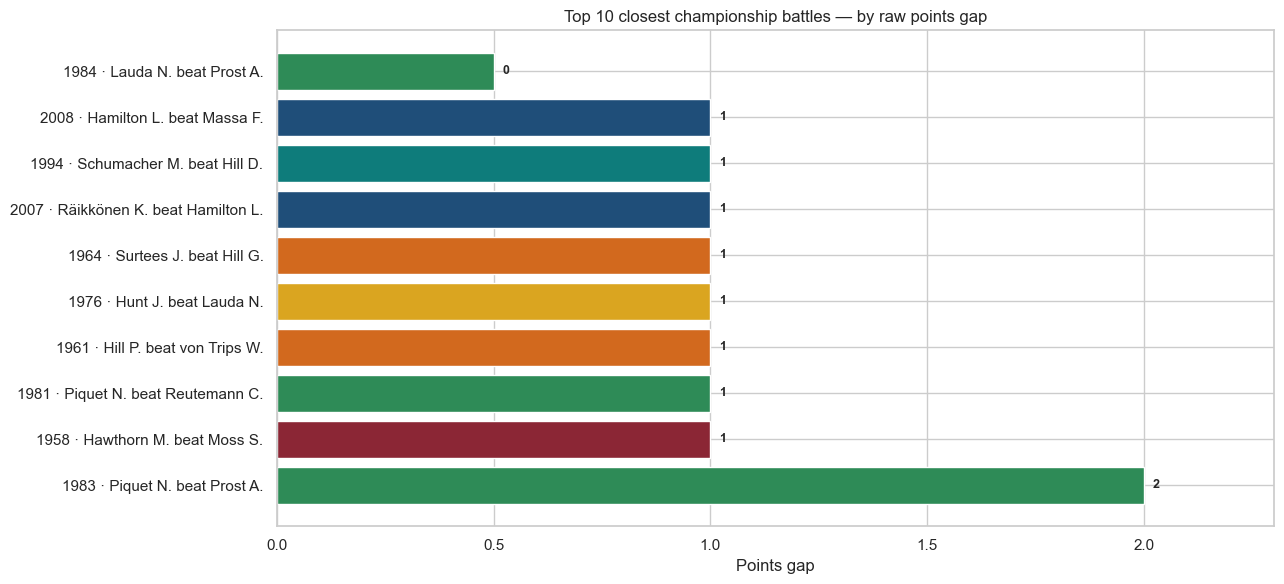

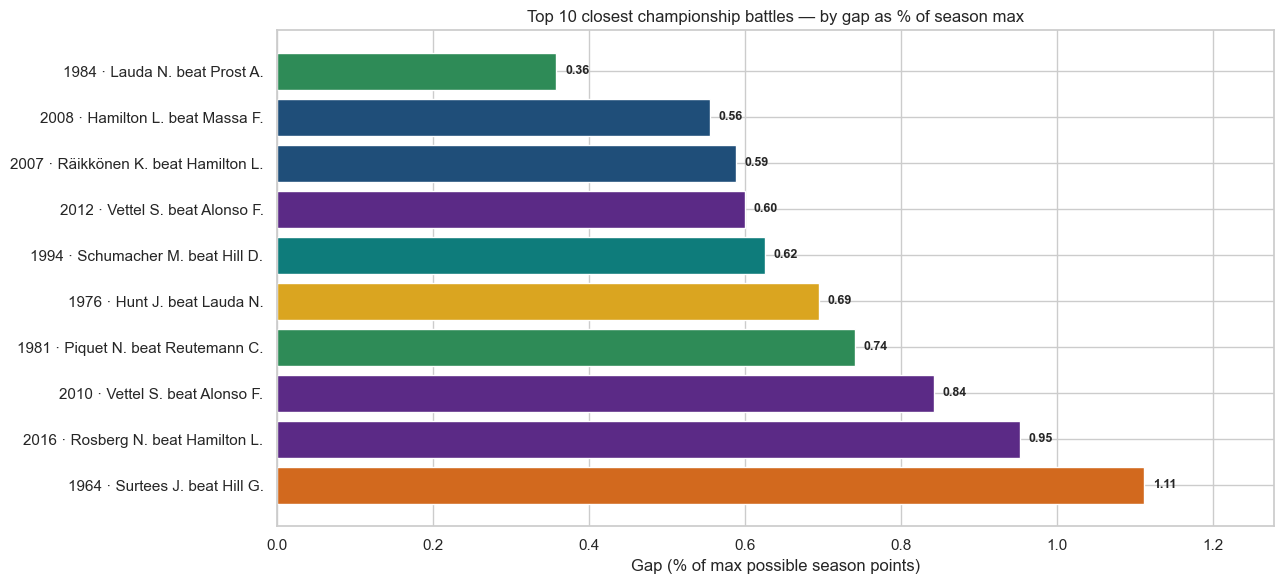

In [54]:
# Champion + runner-up per season
top_two = final_standings[final_standings['position'].isin([1, 2])].copy()
top_two = (top_two.merge(drivers[['driverId', 'driver']], on='driverId')
           .pivot_table(index='year',
                        columns='position',
                        values=['driver', 'points', 'wins'],
                        aggfunc='first'))
top_two.columns = [f'{a}_p{int(b)}' for a, b in top_two.columns]
top_two = top_two.reset_index()
top_two['gap'] = top_two['points_p1'] - top_two['points_p2']

# Normalize against max_possible_points (from 5.1 logic)
top_two = top_two.merge(season_max[['year', 'max_possible']], on='year')
top_two['gap_pct'] = top_two['gap'] / top_two['max_possible'] * 100

# 10 closest by raw gap; 10 closest by %
closest_raw = top_two.nsmallest(10, 'gap')
closest_pct = top_two.nsmallest(10, 'gap_pct')

print('TOP 10 — Closest championship battles by raw points gap:')
print(closest_raw[['year', 'driver_p1', 'points_p1',
                   'driver_p2', 'points_p2', 'gap']].to_string(index=False))
print()
print('TOP 10 — Closest by % of season-max points:')
print(closest_pct[['year', 'driver_p1', 'driver_p2',
                   'points_p1', 'points_p2', 'gap', 'gap_pct']]
      .to_string(index=False))


# Side-by-side bar — bar = gap, label = year + drivers
def _plot_gap(df, title, filename, value_col, value_label):
    df = df.sort_values(value_col, ascending=False).copy()  # smallest at top after barh
    df['decade'] = (df['year'] // 10) * 10

    plt.figure(figsize=(13, 6))
    bar_colors = [DECADE_COLORS[d] for d in df['decade']]
    plt.barh(range(len(df)), df[value_col], color=bar_colors)
    labels = (df['year'].astype(int).astype(str) + ' · '
              + df['driver_p1'] + ' beat ' + df['driver_p2'])
    plt.yticks(range(len(df)), labels)

    for i, row in enumerate(df.itertuples()):
        plt.text(getattr(row, value_col) + df[value_col].max() * 0.01, i,
                 f'{getattr(row, value_col):.2f}' if 'pct' in value_col
                 else f'{getattr(row, value_col):.0f}',
                 va='center', fontsize=9, fontweight='bold')

    plt.title(title)
    plt.xlabel(value_label)
    plt.ylabel('')
    plt.xlim(0, df[value_col].max() * 1.15)
    plt.tight_layout()
    show_and_save(filename)


_plot_gap(closest_raw,
          'Top 10 closest championship battles — by raw points gap',
          '5.3a_closest_raw.png', 'gap', 'Points gap')
_plot_gap(closest_pct,
          'Top 10 closest championship battles — by gap as % of season max',
          '5.3b_closest_pct.png', 'gap_pct', 'Gap (% of max possible season points)')


---
### Chart 5.3c — Closest battles by gap *entering the final round*

5.3a (raw) and 5.3b (% of max) measure the **season-end** gap. But colloquially,
"a close championship" means **decided at the last race** — and that's a
different question.

This view computes the gap **after the penultimate race** of each season, then
keeps only seasons where the title was **mathematically alive** at that point
(gap ≤ max points available in a single race that year). Ranked by smallest
gap-before-final.

**Why this matters:** the 5.3a/b metric undercounts cases where one driver
opens a points gap by *winning the final race itself*. The textbook example is
**2021** — Verstappen and Hamilton went into Abu Dhabi **tied on points**.
Verstappen won the race, so 5.3a shows an 8-point gap (rank #29) and 5.3b shows
1.47 % (rank #16). Neither registers that the title was decided on the last lap
of the last race. 5.3c puts 2021 where it belongs: **tied at #1 with 1974**
(Fittipaldi vs Regazzoni, also tied entering the final).

- **Tables:** `driver_standings`, `races`, `drivers`, `results`
- **Filter:** alive entering the final round (`gap ≤ max_pts_one_race`)
- **Sort:** `gap_before_final` ascending, top 15
- **Bar colour:** F1 era (project convention)
- **"swap" tag in labels:** the runner-up entering the final race went on to win the title

TOP 15 - Closest title battles by gap entering the final round:
 year   driver_pen1   driver_pen2  gap_before_final      champion  swap
 1974 Fittipaldi E.  Regazzoni C.               0.0 Fittipaldi E. False
 2021 Verstappen M.   Hamilton L.               0.0 Verstappen M. False
 1981  Reutemann C.     Piquet N.               1.0     Piquet N.  True
 1961       Hill P.  von Trips W.               1.0       Hill P. False
 1997 Schumacher M. Villeneuve J.               1.0 Villeneuve J.  True
 1994 Schumacher M.       Hill D.               1.0 Schumacher M. False
 1951     Fangio J.     Ascari A.               2.0     Fangio J. False
 1983      Prost A.     Piquet N.               2.0     Piquet N.  True
 1950     Fangio J.    Fagioli L.               2.0     Farina N.  True
 1988      Senna A.      Prost A.               3.0      Senna A. False
 1968       Hill G.    Stewart J.               3.0       Hill G. False
 1976      Lauda N.       Hunt J.               3.0       Hunt J.  True


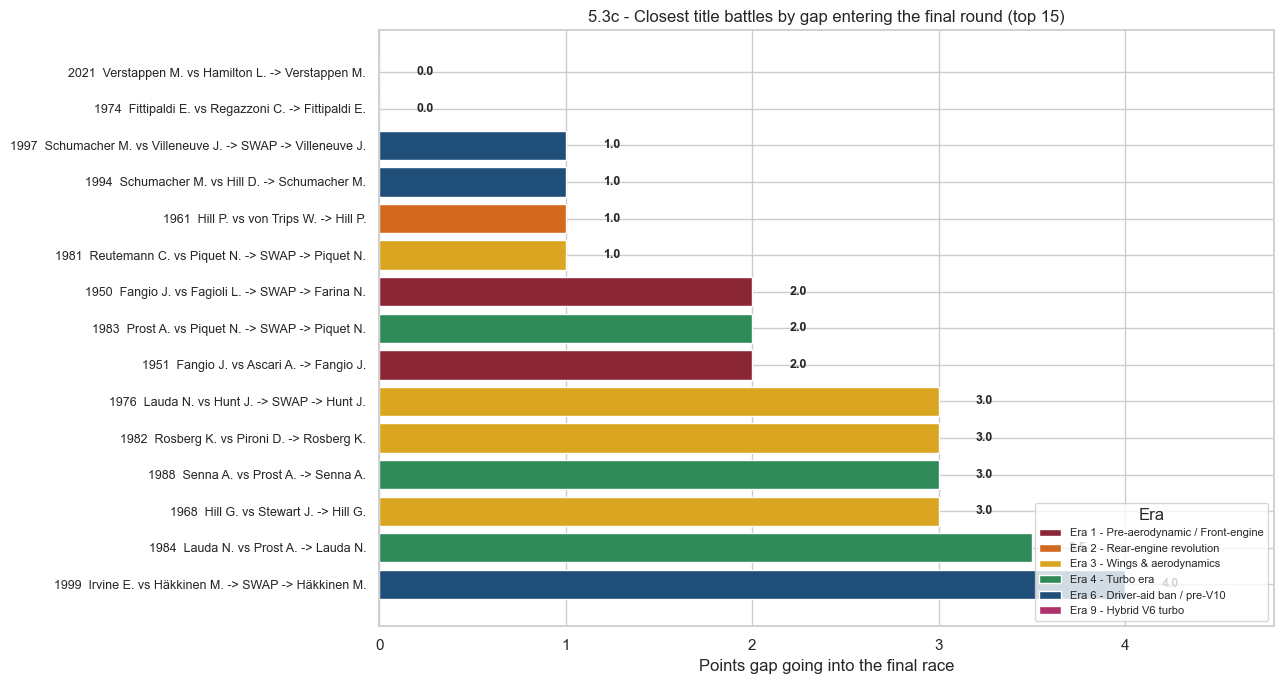

In [55]:
# 5.3c - Gap going INTO the final race of the season.
# Captures championships that were genuinely decided at the last race -
# something the season-end gap (5.3a/b) misses (most famously 2021).

# Step 1: per-year max points awarded in a single race (the final-round swing cap)
race_max_pts = (results.merge(races[['raceId', 'year']], on='raceId')
                       .groupby(['year', 'raceId'])['points'].max()
                       .reset_index())
year_max_one_race = (race_max_pts.groupby('year')['points'].max()
                     .rename('max_one_race').reset_index())

# Step 2: identify the penultimate race of each season (cumcount from the end)
ordered_races = races.sort_values(['year', 'date']).copy()
ordered_races['rank_from_end'] = ordered_races.groupby('year').cumcount(ascending=False)
penultimate = (ordered_races[ordered_races['rank_from_end'] == 1]
               [['raceId', 'year']]
               .rename(columns={'raceId': 'pen_raceId'}))

# Step 3: standings AFTER the penultimate race, pivoted to one row per year
pen_standings = (standings.merge(penultimate, left_on='raceId', right_on='pen_raceId')
                          .merge(drivers[['driverId', 'driver']], on='driverId'))
top2_pen = pen_standings[pen_standings['position'].isin([1, 2])]

pen_wide = top2_pen.pivot_table(
    index='year', columns='position',
    values=['driver', 'points', 'driverId'], aggfunc='first')
pen_wide.columns = [f'{a}_pen{int(b)}' for a, b in pen_wide.columns]
pen_wide = pen_wide.reset_index()
pen_wide['gap_before_final'] = pen_wide['points_pen1'] - pen_wide['points_pen2']

# Step 4: join with the actual champion to detect lead swaps in the final race
champion_per_year = (final_standings[final_standings['position'] == 1]
                     .merge(drivers[['driverId', 'driver']], on='driverId')
                     [['year', 'driverId', 'driver']]
                     .rename(columns={'driverId': 'champ_id', 'driver': 'champion'}))

merged = (pen_wide.merge(champion_per_year, on='year')
                  .merge(year_max_one_race, on='year'))
merged['alive'] = merged['gap_before_final'] <= merged['max_one_race']
merged['swap'] = merged['champ_id'] != merged['driverId_pen1']

# Step 5: filter to "alive entering final" + take 15 closest
alive_seasons = (merged[merged['alive']]
                 .sort_values('gap_before_final')
                 .head(15)
                 .reset_index(drop=True))

print('TOP 15 - Closest title battles by gap entering the final round:')
print(alive_seasons[['year', 'driver_pen1', 'driver_pen2',
                     'gap_before_final', 'champion', 'swap']]
      .to_string(index=False))

# Step 6: horizontal bar chart, colored by era
alive_seasons['era_id'] = alive_seasons['year'].apply(year_to_era)
plot_df = alive_seasons.sort_values('gap_before_final', ascending=False)
bar_colors = [ERA_COLORS[e] for e in plot_df['era_id']]

fig, ax = plt.subplots(figsize=(13, 7))
y_pos = range(len(plot_df))
bars = ax.barh(y_pos, plot_df['gap_before_final'], color=bar_colors, edgecolor='white')
ax.set_yticks(list(y_pos))

labels = []
for r in plot_df.itertuples():
    arrow = ' -> SWAP -> ' if r.swap else ' -> '
    labels.append(f'{int(r.year)}  {r.driver_pen1} vs {r.driver_pen2}'
                  f'{arrow}{r.champion}')
ax.set_yticklabels(labels, fontsize=9)

ax.set_xlabel('Points gap going into the final race')
ax.set_title('5.3c - Closest title battles by gap entering the final round (top 15)')
ax.set_xlim(0, max(plot_df['gap_before_final'].max(), 1.0) * 1.20)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(row.gap_before_final + 0.2, i,
            f'{row.gap_before_final:.1f}',
            va='center', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
eras_present = sorted(plot_df['era_id'].unique())
era_legend = [
    Patch(facecolor=ERA_COLORS[e],
          label=f"Era {e} - {eras_df.loc[eras_df['era_id'] == e, 'name_en'].iloc[0]}")
    for e in eras_present
]
ax.legend(handles=era_legend, loc='lower right', title='Era', fontsize=8)
plt.tight_layout()
show_and_save('5.3c_closest_before_final.png')

**SQL equivalent**
```sql
-- 5.3: Closest championship battles (champion vs runner-up gap)
WITH season_end AS (
    SELECT year, raceId
    FROM   (SELECT year, raceId, date,
                   ROW_NUMBER() OVER (PARTITION BY year ORDER BY date DESC) rn
            FROM   races
            WHERE  name NOT LIKE '%Indianapolis%') t
    WHERE  rn = 1
),
top2 AS (
    SELECT s.driverId, s.position, s.points, ra.year
    FROM   driver_standings s
    JOIN   season_end       se ON s.raceId = se.raceId
    JOIN   races            ra ON s.raceId = ra.raceId
    WHERE  s.position IN (1, 2)
)
SELECT
    p1.year,
    d1.surname || ' ' || SUBSTR(d1.forename,1,1) || '.' AS champion,
    d2.surname || ' ' || SUBSTR(d2.forename,1,1) || '.' AS runner_up,
    p1.points - p2.points AS gap
FROM   top2 p1
JOIN   top2 p2 ON p1.year = p2.year AND p1.position = 1 AND p2.position = 2
JOIN   drivers d1 ON p1.driverId = d1.driverId
JOIN   drivers d2 ON p2.driverId = d2.driverId
ORDER  BY gap ASC
LIMIT  10;
```


---
### Chart 5.4 — Biggest championship blowouts (largest gap)

Same data as 5.3 but sorted descending. The raw-points version is dominated by the modern era (25-pt wins inflate gaps); the %-of-max version surfaces dominant *seasons* across all eras (Schumacher 2002, Vettel 2011, Verstappen 2023).


TOP 10 — Biggest blowouts by raw points gap:
 year     driver_p1  points_p1      driver_p2  points_p2   gap
 2023 Verstappen M.      575.0       Pérez S.      285.0 290.0
 2013     Vettel S.      397.0      Alonso F.      242.0 155.0
 2022 Verstappen M.      454.0     Leclerc C.      308.0 146.0
 2020   Hamilton L.      347.0      Bottas V.      223.0 124.0
 2011     Vettel S.      392.0      Button J.      270.0 122.0
 2018   Hamilton L.      408.0      Vettel S.      320.0  88.0
 2019   Hamilton L.      413.0      Bottas V.      326.0  87.0
 2002 Schumacher M.      144.0 Barrichello R.       77.0  67.0
 2014   Hamilton L.      384.0     Rosberg N.      317.0  67.0
 2024 Verstappen M.      437.0      Norris L.      374.0  63.0

TOP 10 — Biggest blowouts by % of season-max points:
 year     driver_p1      driver_p2  points_p1  points_p2   gap   gap_pct
 2023 Verstappen M.       Pérez S.      575.0      285.0 290.0 51.971326
 2002 Schumacher M. Barrichello R.      144.0       77.0  67.0

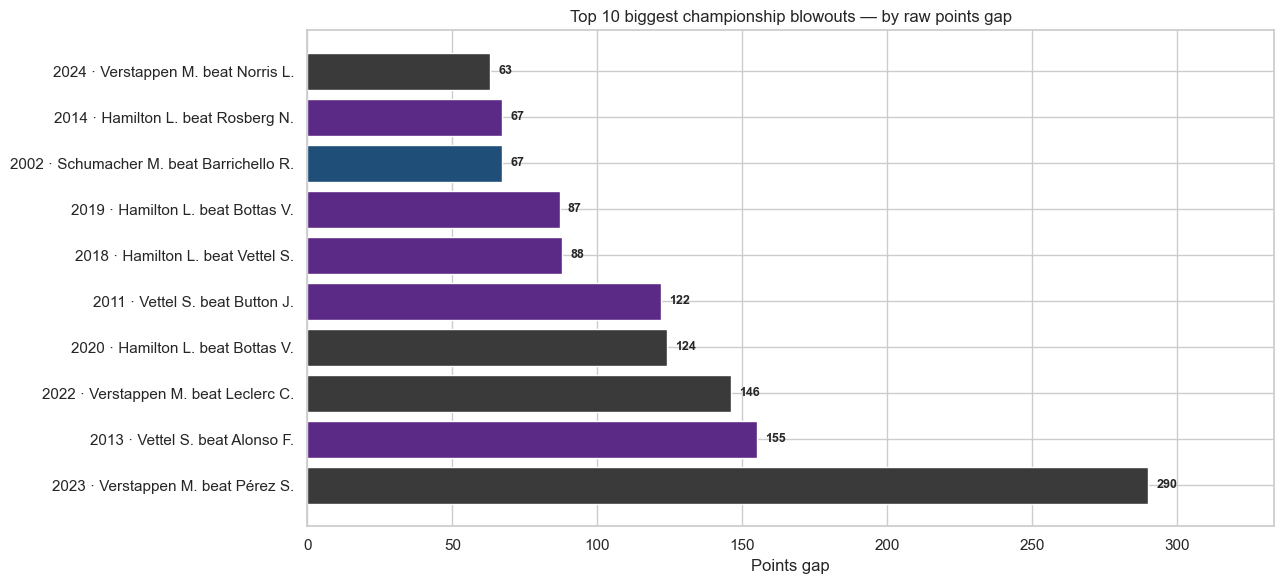

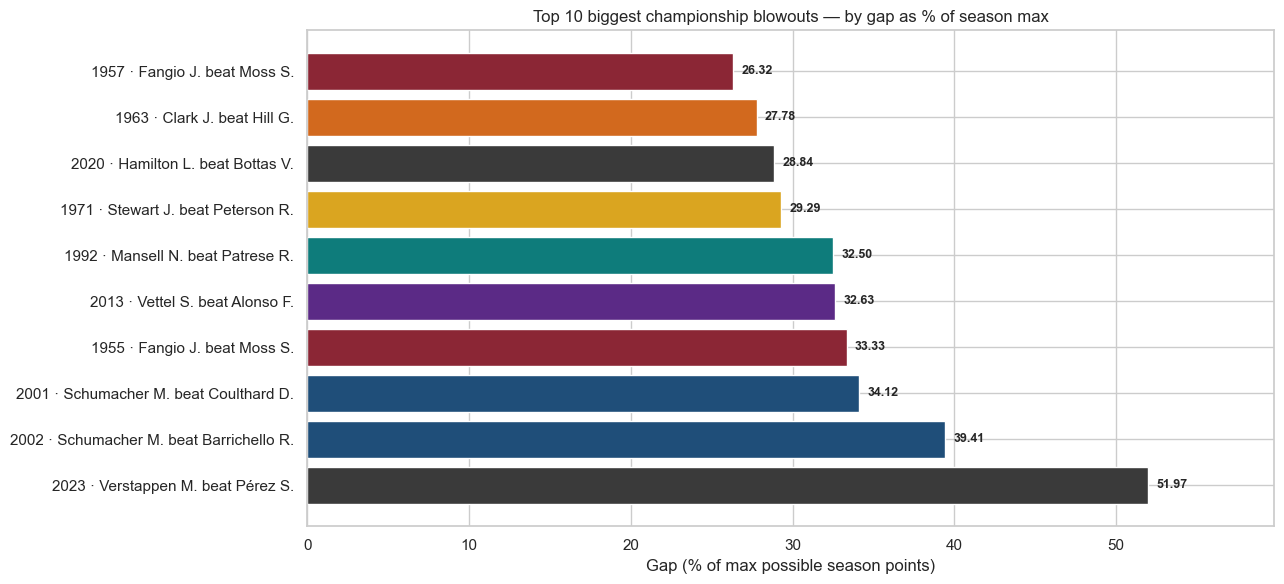

In [56]:
biggest_raw = top_two.nlargest(10, 'gap')
biggest_pct = top_two.nlargest(10, 'gap_pct')

print('TOP 10 — Biggest blowouts by raw points gap:')
print(biggest_raw[['year', 'driver_p1', 'points_p1',
                   'driver_p2', 'points_p2', 'gap']].to_string(index=False))
print()
print('TOP 10 — Biggest blowouts by % of season-max points:')
print(biggest_pct[['year', 'driver_p1', 'driver_p2',
                   'points_p1', 'points_p2', 'gap', 'gap_pct']]
      .to_string(index=False))


_plot_gap(biggest_raw,
          'Top 10 biggest championship blowouts — by raw points gap',
          '5.4a_biggest_raw.png', 'gap', 'Points gap')
_plot_gap(biggest_pct,
          'Top 10 biggest championship blowouts — by gap as % of season max',
          '5.4b_biggest_pct.png', 'gap_pct', 'Gap (% of max possible season points)')


**SQL equivalent** — same query as 5.3 with `ORDER BY gap DESC`.


---
### Chart 5.5 — Seasons with the most different race winners

Per year, count distinct drivers who won at least one race. A high count = wide-open competitive season; a low count = dominant era.

#### Caveats worth knowing before reading the chart
- **Hard ceiling**: distinct winners can never exceed `min(races_that_year, drivers_in_field)`. A 1951 season with 7 races can't have more than 7 winners — so a "raw count of 11" in 1982 is more impressive than it looks vs. a "raw count of 8" in 2012, even though 2012 had more races.
- **The ratio fixes this.** `distinct_winners ÷ races` puts every season on a 0–1 scale — that's chart 5.5b below.
- **Context matters more than the number.** 1982's record-tying 11 winners came from a chaotic season (Villeneuve and Paletti died, Pironi was career-ended), not pure pace parity. Era + circumstances should always sit next to the metric — that's chart 5.5d.
- **2020s are noisy.** 2020 (COVID), 2021 (controversies), 2022 (regs overhaul) are extreme outliers for different reasons. Anything we say about "modern trends" with fewer than 10 seasons of data should be flagged, not concluded.

This cell shows the **raw count** view. 5.5b–5.5d below show the analytically fairer angles.


TOP 10 seasons by distinct race winner count:
 year  distinct_winners  races    ratio
 1982                11     16 0.687500
 1975                 9     14 0.642857
 1977                 8     17 0.470588
 1983                 8     15 0.533333
 1985                 8     16 0.500000
 2003                 8     16 0.500000
 2012                 8     20 0.400000
 1968                 7     12 0.583333
 1970                 7     13 0.538462
 1974                 7     15 0.466667

TOP 10 seasons by ratio (distinct winners / races):
 year  distinct_winners  races    ratio
 1951                 5      7 0.714286
 1982                11     16 0.687500
 1975                 9     14 0.642857
 1959                 5      8 0.625000
 1961                 5      8 0.625000
 1968                 7     12 0.583333
 1956                 4      7 0.571429
 1966                 5      9 0.555556
 1967                 6     11 0.545455
 1971                 6     11 0.545455


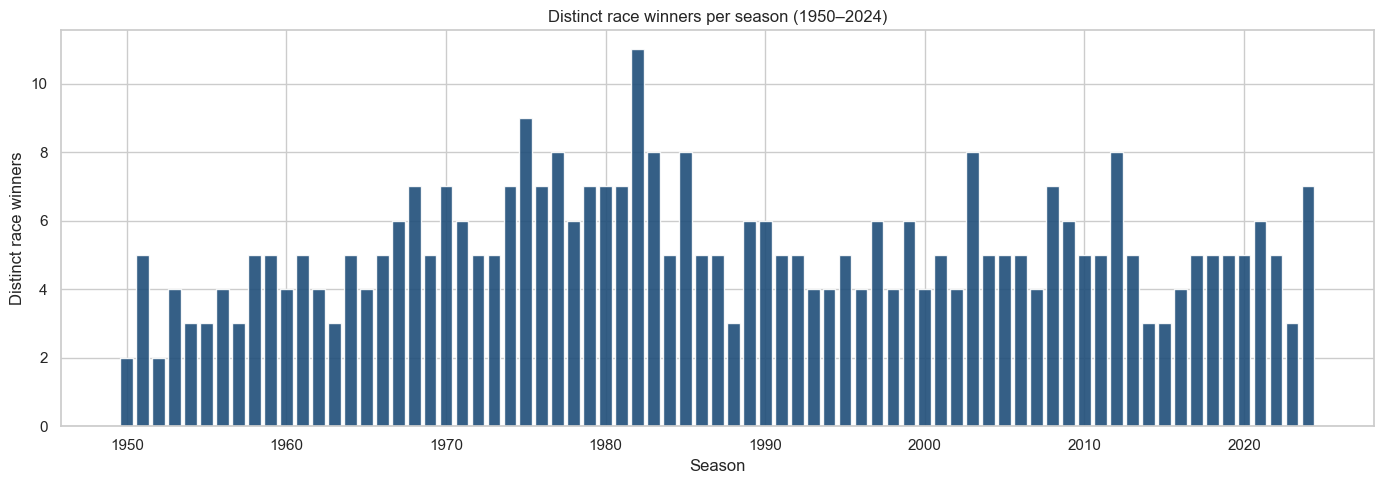

In [57]:
winners_per_year = (
    results[results['positionOrder'] == 1]
    .merge(races[['raceId', 'year']], on='raceId')
    .groupby('year')
    .agg(distinct_winners=('driverId', 'nunique'),
         races=('raceId', 'nunique'))
    .reset_index()
)
winners_per_year['ratio'] = winners_per_year['distinct_winners'] / winners_per_year['races']

top10_count = winners_per_year.nlargest(10, 'distinct_winners')
top10_ratio = winners_per_year.nlargest(10, 'ratio')

print('TOP 10 seasons by distinct race winner count:')
print(top10_count.to_string(index=False))
print()
print('TOP 10 seasons by ratio (distinct winners / races):')
print(top10_ratio.to_string(index=False))


# Single-axis bar chart of distinct winners per season.
# The ratio is still computed (and shown in the table above) — we just don't
# overlay it as a competing red line anymore. See feedback_chart_design.md.
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(winners_per_year['year'], winners_per_year['distinct_winners'],
       color='#1F4E79', edgecolor='white', alpha=0.9)
ax.set_xlabel('Season')
ax.set_ylabel('Distinct race winners')
ax.set_title('Distinct race winners per season (1950–2024)')
fig.tight_layout()
show_and_save('5.5_distinct_winners_per_season.png')


**SQL equivalent**
```sql
-- 5.5: Distinct winners per season + ratio
WITH wins AS (
    SELECT ra.year, r.driverId, r.raceId
    FROM   results r
    JOIN   races   ra ON r.raceId = ra.raceId
    WHERE  r.positionOrder = 1
      AND  ra.name NOT LIKE '%Indianapolis%'
)
SELECT  year,
        COUNT(DISTINCT driverId) AS distinct_winners,
        COUNT(DISTINCT raceId)   AS races,
        1.0 * COUNT(DISTINCT driverId) / COUNT(DISTINCT raceId) AS ratio
FROM    wins
GROUP   BY year
ORDER   BY ratio DESC, distinct_winners DESC;
```


---
### Chart 5.5b — Distinct-winners ratio across all seasons

The fair comparison: `distinct_winners ÷ races`. **Bounded 0–1**, so a 7-race season and a 24-race season are directly comparable.

A ratio near 1.0 means almost every race had a different winner (peak competitive chaos). A ratio near 0.1 means one or two drivers swept the year (peak dominance).


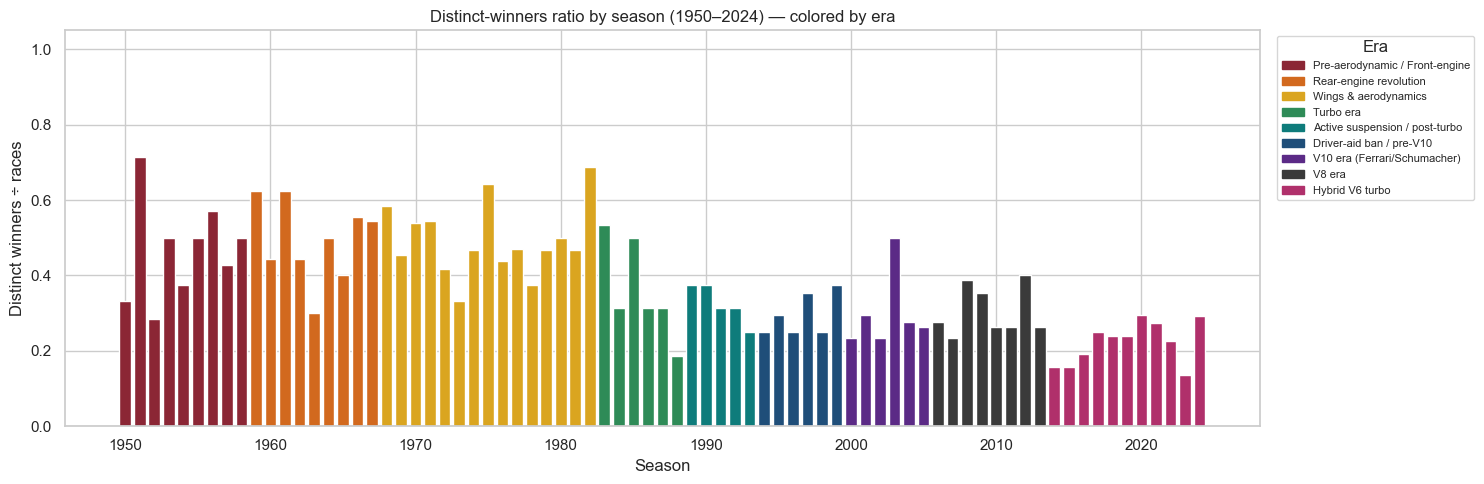

TOP 10 most competitive seasons (highest distinct-winners ratio):
 year  distinct_winners  races  ratio
 1951                 5      7  0.714
 1982                11     16  0.688
 1975                 9     14  0.643
 1959                 5      8  0.625
 1961                 5      8  0.625
 1968                 7     12  0.583
 1956                 4      7  0.571
 1966                 5      9  0.556
 1967                 6     11  0.545
 1971                 6     11  0.545


In [58]:
# Reuses winners_per_year from 5.5 (recomputed here so this cell can stand alone)
winners_per_year = (
    results[results['positionOrder'] == 1]
    .merge(races[['raceId', 'year']], on='raceId')
    .groupby('year')
    .agg(distinct_winners=('driverId', 'nunique'),
         races=('raceId', 'nunique'))
    .reset_index()
)
winners_per_year['ratio'] = winners_per_year['distinct_winners'] / winners_per_year['races']
winners_per_year['era_id'] = winners_per_year['year'].apply(year_to_era)

# Color each bar by its era — consistent palette across the whole notebook
bar_colors = [ERA_COLORS[int(e)] if pd.notna(e) else '#999999'
              for e in winners_per_year['era_id']]

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(winners_per_year['year'], winners_per_year['ratio'],
       color=bar_colors, edgecolor='white')
ax.set_xlabel('Season')
ax.set_ylabel('Distinct winners ÷ races')
ax.set_ylim(0, 1.05)
ax.set_title('Distinct-winners ratio by season (1950–2024) — colored by era')

# Era legend
used_eras = sorted(int(e) for e in winners_per_year['era_id'].dropna().unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=ERA_COLORS[e],
                         label=eras_df.loc[eras_df['era_id'] == e, 'name_en'].iloc[0])
           for e in used_eras]
ax.legend(handles=handles, title='Era', loc='upper left',
          bbox_to_anchor=(1.01, 1.0), frameon=True, fontsize=8)

plt.tight_layout()
show_and_save('5.5b_distinct_winners_ratio.png')


# Top 10 most competitive seasons by ratio
top10_ratio = winners_per_year.nlargest(10, 'ratio')[
    ['year', 'distinct_winners', 'races', 'ratio']]
print('TOP 10 most competitive seasons (highest distinct-winners ratio):')
print(top10_ratio.round({'ratio': 3}).to_string(index=False))


---
### Chart 5.5c — The dominance view: fewest winners + cars vs drivers

Two ideas in one chart:

1. **Bottom 10 by ratio** — the most dominant seasons in F1 history. These usually pin to a specific car/regulation combo (McLaren-Honda MP4/4 in 1988, Mercedes W11 in 2020, RB19 in 2023).
2. **Distinct *drivers* vs distinct *teams*** per season. They tell different stories:
   - 1988: **2 drivers** (Senna, Prost) and **1 team** (McLaren) won — the cars were dominant *and* the drivers were exclusive.
   - 1982: **11 drivers** and **7 teams** won — both genuinely wide-open.
   - 2002: **3 drivers**, **3 teams** — Schumacher era, but a couple of other top teams could win on the right Sunday.

The `drivers ÷ teams` ratio tells you whether a "diverse" season was about cars or about drivers.


TOP 10 most DOMINANT seasons (lowest distinct-winners ratio):
 year  distinct_drivers  distinct_teams  races  driver_ratio                      name_en
 2023                 3               2     22         0.136              Hybrid V6 turbo
 2014                 3               2     19         0.158              Hybrid V6 turbo
 2015                 3               2     19         0.158              Hybrid V6 turbo
 1988                 3               2     16         0.188                    Turbo era
 2016                 4               2     21         0.190              Hybrid V6 turbo
 2022                 5               3     22         0.227              Hybrid V6 turbo
 2000                 4               2     17         0.235 V10 era (Ferrari/Schumacher)
 2002                 4               3     17         0.235 V10 era (Ferrari/Schumacher)
 2007                 4               2     17         0.235                       V8 era
 2018                 5               

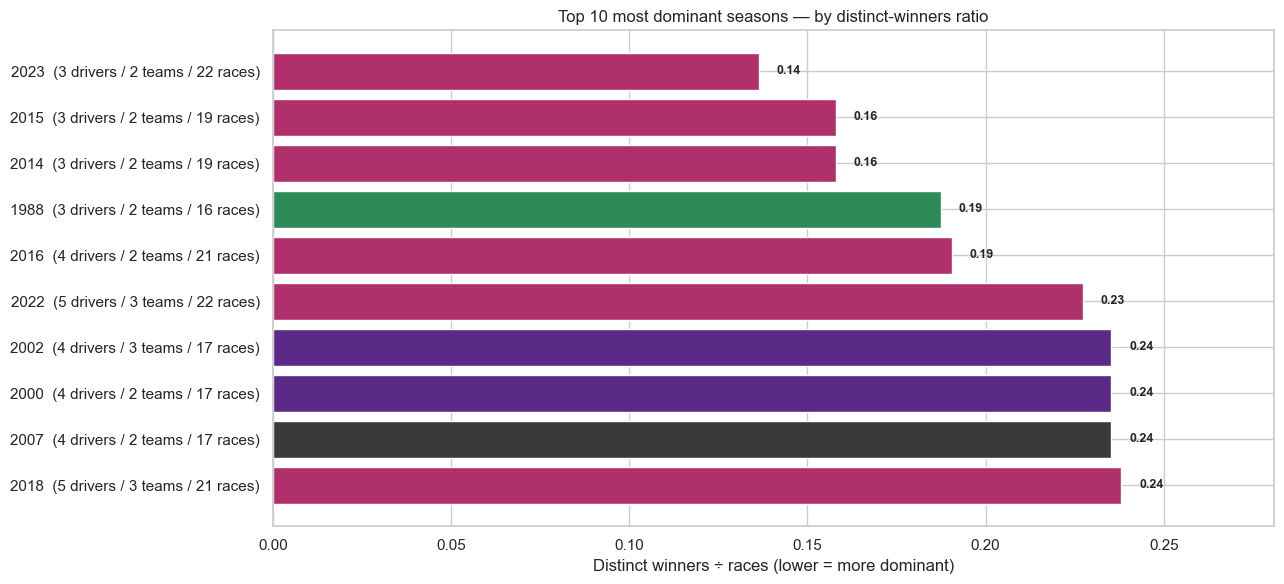

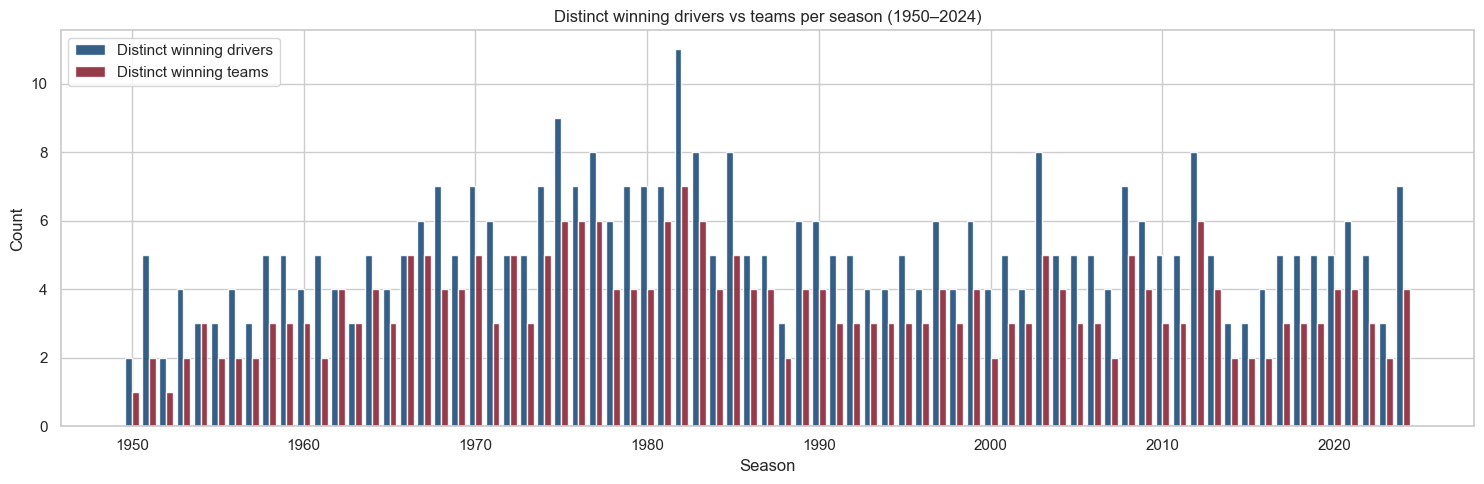

In [59]:
# --- Part A: count distinct winning DRIVERS AND TEAMS per season ---
winners_full = (
    results[results['positionOrder'] == 1]
    .merge(races[['raceId', 'year']], on='raceId')
    .groupby('year')
    .agg(distinct_drivers=('driverId', 'nunique'),
         distinct_teams=('constructorId', 'nunique'),
         races=('raceId', 'nunique'))
    .reset_index()
)
winners_full['driver_ratio'] = winners_full['distinct_drivers'] / winners_full['races']
winners_full['team_ratio']   = winners_full['distinct_teams']   / winners_full['races']
winners_full['drivers_per_team'] = (
    winners_full['distinct_drivers'] / winners_full['distinct_teams']
)
# Attach era_id as a regular column up front — makes downstream merges trivial
winners_full['era_id'] = winners_full['year'].apply(year_to_era)


# --- Part B: bottom 10 most-dominant seasons (lowest driver ratio) ---
bottom10 = (winners_full
            .nsmallest(10, 'driver_ratio')
            .merge(eras_df[['era_id', 'name_en']], on='era_id', how='left')
            .sort_values('driver_ratio'))
print('TOP 10 most DOMINANT seasons (lowest distinct-winners ratio):')
print(bottom10[['year', 'distinct_drivers', 'distinct_teams',
                'races', 'driver_ratio', 'name_en']]
      .round({'driver_ratio': 3})
      .to_string(index=False))


# --- Plot the bottom 10 as a horizontal bar chart, colored by era ---
fig, ax = plt.subplots(figsize=(13, 6))
plot_df = bottom10.sort_values('driver_ratio', ascending=False)  # asc → biggest at top after barh
bar_colors = [ERA_COLORS[int(e)] if pd.notna(e) else '#999999'
              for e in plot_df['era_id']]
ax.barh(range(len(plot_df)), plot_df['driver_ratio'],
        color=bar_colors, edgecolor='white')

labels = (plot_df['year'].astype(str)
          + '  ('
          + plot_df['distinct_drivers'].astype(str) + ' drivers / '
          + plot_df['distinct_teams'].astype(str) + ' teams / '
          + plot_df['races'].astype(str) + ' races)')
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(labels)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(row.driver_ratio + 0.005, i, f'{row.driver_ratio:.2f}',
            va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, plot_df['driver_ratio'].max() * 1.18)
ax.set_xlabel('Distinct winners ÷ races (lower = more dominant)')
ax.set_title('Top 10 most dominant seasons — by distinct-winners ratio')
plt.tight_layout()
show_and_save('5.5c_dominant_seasons.png')


# --- Part C: drivers-vs-teams winner counts over time (grouped bar chart) ---
fig, ax = plt.subplots(figsize=(15, 5))
width = 0.4
x = winners_full['year'].values
ax.bar(x - width/2, winners_full['distinct_drivers'], width=width,
       color='#1F4E79', edgecolor='white', alpha=0.9,
       label='Distinct winning drivers')
ax.bar(x + width/2, winners_full['distinct_teams'], width=width,
       color='#8B2635', edgecolor='white', alpha=0.9,
       label='Distinct winning teams')
ax.set_xlabel('Season')
ax.set_ylabel('Count')
ax.set_title('Distinct winning drivers vs teams per season (1950–2024)')
ax.legend(loc='upper left')
plt.tight_layout()
show_and_save('5.5c_drivers_vs_teams.png')


---
### Chart 5.5d — Competitiveness by era

Average distinct-winners ratio within each F1 era. Smooths out year-to-year noise so we can answer "was the V8 era genuinely more competitive than the Hybrid V6 era, or did it just feel that way?".

Read this together with [[feedback-dataset-caveats]]: short eras (Active Suspension, 1989–1993) carry more single-season risk than long eras.


Competitiveness by era (averages within each era):
 era_id                        name_en  year_first  year_last  seasons  avg_distinct_drivers  avg_distinct_teams  avg_driver_ratio  avg_team_ratio
      1 Pre-aerodynamic / Front-engine        1950       1958        9                   3.4                 2.0             0.468           0.269
      2         Rear-engine revolution        1959       1967        9                   4.6                 3.6             0.493           0.379
      3           Wings & aerodynamics        1968       1982       15                   6.9                 4.8             0.492           0.340
      4                      Turbo era        1983       1988        6                   5.7                 4.2             0.360           0.265
      5 Active suspension / post-turbo        1989       1993        5                   5.2                 3.4             0.325           0.212
      6       Driver-aid ban / pre-V10        1994       1999      

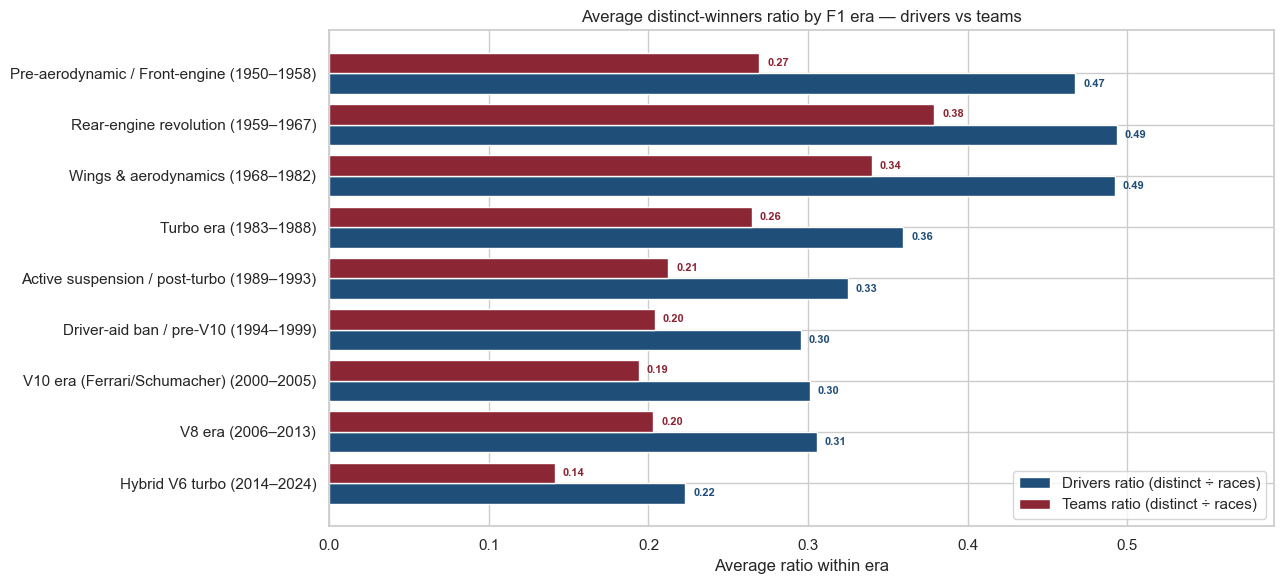

In [60]:
# Reuses winners_full (distinct drivers + teams per season) from 5.5c
winners_full['era_id'] = winners_full['year'].apply(year_to_era)

era_competition = (
    winners_full.dropna(subset=['era_id'])
    .assign(era_id=lambda d: d['era_id'].astype(int))
    .groupby('era_id')
    .agg(seasons=('year', 'count'),
         year_first=('year', 'min'),
         year_last=('year', 'max'),
         avg_distinct_drivers=('distinct_drivers', 'mean'),
         avg_distinct_teams=('distinct_teams', 'mean'),
         avg_driver_ratio=('driver_ratio', 'mean'),
         avg_team_ratio=('team_ratio', 'mean'))
    .reset_index()
    .merge(eras_df[['era_id', 'name_en']], on='era_id')
    .sort_values('era_id')
)

print('Competitiveness by era (averages within each era):')
print(era_competition[['era_id', 'name_en', 'year_first', 'year_last',
                       'seasons', 'avg_distinct_drivers', 'avg_distinct_teams',
                       'avg_driver_ratio', 'avg_team_ratio']]
      .round({'avg_distinct_drivers': 1, 'avg_distinct_teams': 1,
              'avg_driver_ratio': 3, 'avg_team_ratio': 3})
      .to_string(index=False))


# Horizontal grouped bar — drivers ratio + teams ratio side-by-side per era
fig, ax = plt.subplots(figsize=(13, 6))
plot_df = era_competition.sort_values('era_id', ascending=False)  # reversed for barh
y = list(range(len(plot_df)))
height = 0.4
ax.barh([i - height/2 for i in y], plot_df['avg_driver_ratio'],
        height=height, color='#1F4E79', edgecolor='white',
        label='Drivers ratio (distinct ÷ races)')
ax.barh([i + height/2 for i in y], plot_df['avg_team_ratio'],
        height=height, color='#8B2635', edgecolor='white',
        label='Teams ratio (distinct ÷ races)')

labels = (plot_df['name_en']
          + ' ('
          + plot_df['year_first'].astype(str) + '–'
          + plot_df['year_last'].astype(str) + ')')
ax.set_yticks(y)
ax.set_yticklabels(labels)

# Numeric labels on each bar
for i, row in enumerate(plot_df.itertuples()):
    ax.text(row.avg_driver_ratio + 0.005, i - height/2,
            f'{row.avg_driver_ratio:.2f}',
            va='center', fontsize=8, color='#1F4E79', fontweight='bold')
    ax.text(row.avg_team_ratio + 0.005, i + height/2,
            f'{row.avg_team_ratio:.2f}',
            va='center', fontsize=8, color='#8B2635', fontweight='bold')

ax.set_xlim(0, max(plot_df['avg_driver_ratio'].max(),
                   plot_df['avg_team_ratio'].max()) * 1.20)
ax.set_xlabel('Average ratio within era')
ax.set_title('Average distinct-winners ratio by F1 era — drivers vs teams')
ax.legend(loc='lower right')
plt.tight_layout()
show_and_save('5.5d_competitiveness_by_era.png')


---
### Chart 5.6 — Seasons where the champion had fewer wins than the runner-up

The runner-up in `final_standings` has a `wins` column. If it's **higher** than the champion's, the champion won the title on consistency rather than peak speed.

Output as a table — rare event (under 5 in F1 history). For each: champion vs runner-up wins + final points gap, so the storyline is clear.


Seasons where the champion had FEWER wins than the runner-up: 9

 year    champion  champ_wins  champ_pts   runner_up  runner_wins  runner_pts  win_deficit
 1958 Hawthorn M.           1       42.0     Moss S.            4        41.0            3
 1982  Rosberg K.           1       44.0   Pironi D.            2        39.0            1
 1983   Piquet N.           3       59.0    Prost A.            4        57.0            1
 1984    Lauda N.           5       72.0    Prost A.            7        71.5            2
 1986    Prost A.           4       72.0  Mansell N.            5        70.0            1
 1987   Piquet N.           3       73.0  Mansell N.            6        61.0            3
 1989    Prost A.           4       76.0    Senna A.            6        60.0            2
 2008 Hamilton L.           5       98.0    Massa F.            6        97.0            1
 2016  Rosberg N.           9      385.0 Hamilton L.           10       380.0            1


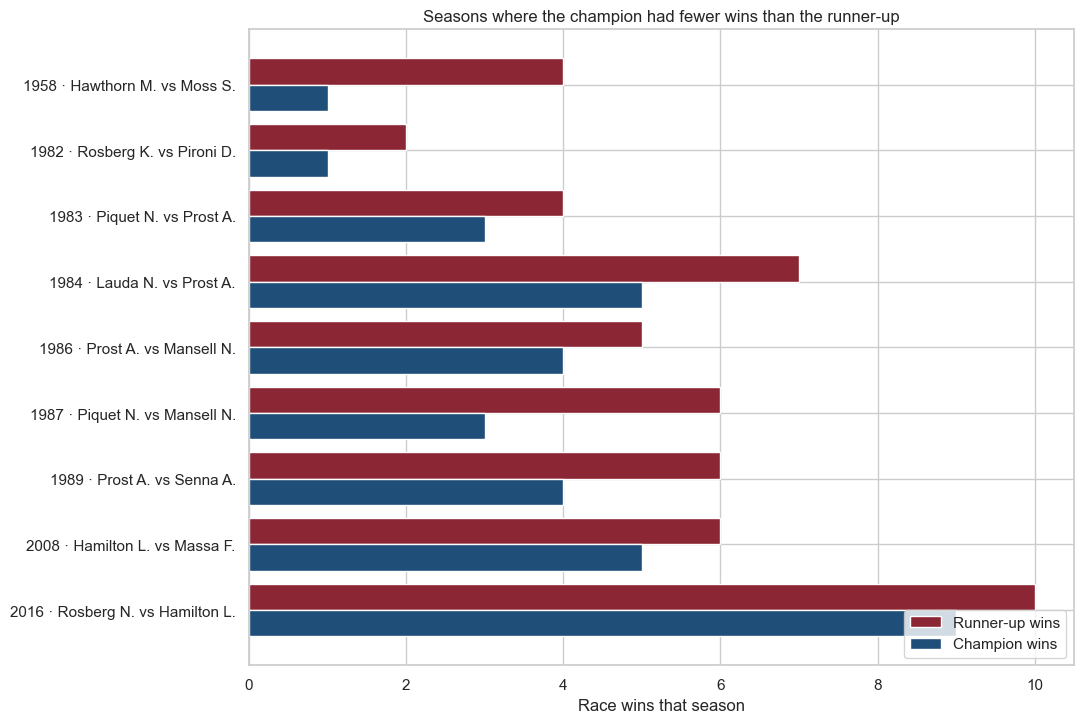

In [61]:
champ = (final_standings[final_standings['position'] == 1]
         [['year', 'driverId', 'points', 'wins']]
         .rename(columns={'driverId': 'champ_id', 'points': 'champ_pts',
                          'wins': 'champ_wins'}))

runner = (final_standings[final_standings['position'] == 2]
          [['year', 'driverId', 'points', 'wins']]
          .rename(columns={'driverId': 'runner_id', 'points': 'runner_pts',
                           'wins': 'runner_wins'}))

cmp = (champ.merge(runner, on='year')
       .merge(drivers[['driverId', 'driver']]
              .rename(columns={'driverId': 'champ_id', 'driver': 'champion'}),
              on='champ_id')
       .merge(drivers[['driverId', 'driver']]
              .rename(columns={'driverId': 'runner_id', 'driver': 'runner_up'}),
              on='runner_id'))
cmp['win_deficit'] = cmp['runner_wins'] - cmp['champ_wins']

odd_titles = (cmp[cmp['win_deficit'] > 0]
              .sort_values('year')
              [['year', 'champion', 'champ_wins', 'champ_pts',
                'runner_up', 'runner_wins', 'runner_pts', 'win_deficit']])

print(f'Seasons where the champion had FEWER wins than the runner-up: {len(odd_titles)}')
print()
print(odd_titles.to_string(index=False))

# Bar chart — show as 'wins' grouped pairs (champ vs runner-up) by year
plot_df = odd_titles.copy()
if len(plot_df):
    plot_df['decade'] = (plot_df['year'] // 10) * 10

    fig, ax = plt.subplots(figsize=(11, max(3, 0.6 * len(plot_df) + 2)))
    y = range(len(plot_df))
    width = 0.4
    ax.barh([i - width/2 for i in y], plot_df['runner_wins'],
            height=width, color='#8B2635', edgecolor='white',
            label='Runner-up wins')
    ax.barh([i + width/2 for i in y], plot_df['champ_wins'],
            height=width, color='#1F4E79', edgecolor='white',
            label='Champion wins')

    labels = (plot_df['year'].astype(str) + ' · '
              + plot_df['champion'] + ' vs ' + plot_df['runner_up'])
    ax.set_yticks(list(y))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('Race wins that season')
    ax.set_title('Seasons where the champion had fewer wins than the runner-up')
    ax.legend(loc='lower right')
    plt.tight_layout()
    show_and_save('5.6_champion_fewer_wins.png')
else:
    print('Nothing to plot — all champions had >= as many wins as the runner-up.')


**SQL equivalent**
```sql
-- 5.6: Seasons where champion had fewer wins than runner-up
WITH season_end AS (
    SELECT year, raceId
    FROM   (SELECT year, raceId, date,
                   ROW_NUMBER() OVER (PARTITION BY year ORDER BY date DESC) rn
            FROM   races
            WHERE  name NOT LIKE '%Indianapolis%') t
    WHERE  rn = 1
),
top2 AS (
    SELECT ra.year, s.driverId, s.position, s.points, s.wins
    FROM   driver_standings s
    JOIN   season_end       se ON s.raceId = se.raceId
    JOIN   races            ra ON s.raceId = ra.raceId
    WHERE  s.position IN (1, 2)
)
SELECT
    p1.year,
    d1.surname || ' ' || SUBSTR(d1.forename,1,1) || '.' AS champion,
    p1.wins  AS champion_wins,
    d2.surname || ' ' || SUBSTR(d2.forename,1,1) || '.' AS runner_up,
    p2.wins  AS runner_up_wins,
    p2.wins - p1.wins AS win_deficit
FROM   top2 p1
JOIN   top2 p2 ON p1.year = p2.year AND p1.position = 1 AND p2.position = 2
JOIN   drivers d1 ON p1.driverId = d1.driverId
JOIN   drivers d2 ON p2.driverId = d2.driverId
WHERE  p2.wins > p1.wins
ORDER  BY p1.year;
```


### Chart 5.7 — Average season start and end dates

For each season, take the **earliest** and **latest** race date and convert
both to day-of-year. Average across all seasons. Output: a printed
summary plus a chart where each season is a vertical bar spanning its
start-day to its end-day, era-coloured.

- **Tables:** `races`
- **Chart:** Year on x-axis (every year labelled), day-of-year on y-axis


Average start: 10 March (DOY 69) · Average end: 29 October (DOY 302)


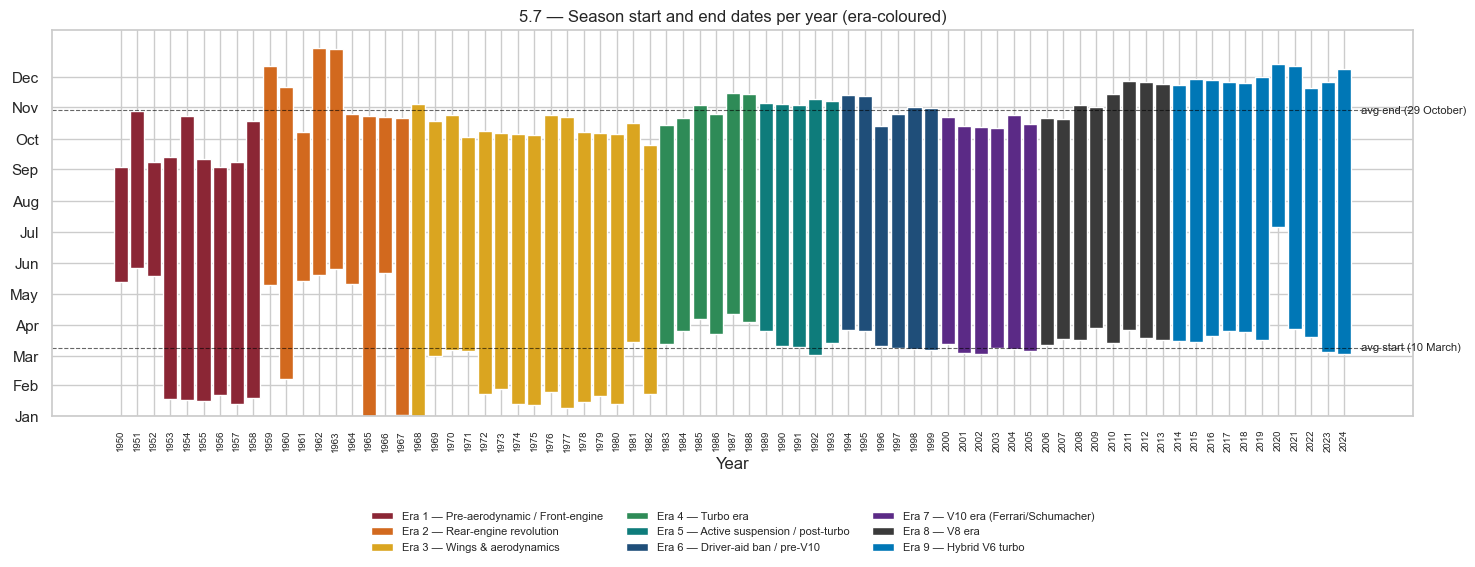

In [62]:
ERA_COLORS = {
    1: '#8B2635', 2: '#D2691E', 3: '#DAA520', 4: '#2E8B57', 5: '#0E7C7B',
    6: '#1F4E79', 7: '#5B2A86', 8: '#3A3A3A', 9: '#0077B6',
}

import datetime as _dt

races['date'] = pd.to_datetime(races['date'])
season_dates = (
    races.groupby('year')
         .agg(start_date=('date', 'min'), end_date=('date', 'max'))
         .reset_index()
)
season_dates['start_doy'] = season_dates['start_date'].dt.dayofyear
season_dates['end_doy']   = season_dates['end_date'].dt.dayofyear
season_dates['era_id']    = season_dates['year'].apply(year_to_era)
season_dates['color']     = season_dates['era_id'].map(ERA_COLORS)

avg_start_doy = season_dates['start_doy'].mean()
avg_end_doy   = season_dates['end_doy'].mean()


def doy_to_label(doy, ref_year=2001):
    return (_dt.date(ref_year, 1, 1)
            + _dt.timedelta(days=int(round(doy)) - 1)).strftime('%d %B')


print(f"Average start: {doy_to_label(avg_start_doy)} "
      f"(DOY {avg_start_doy:.0f}) · "
      f"Average end: {doy_to_label(avg_end_doy)} "
      f"(DOY {avg_end_doy:.0f})")

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(season_dates['year'],
       season_dates['end_doy'] - season_dates['start_doy'],
       bottom=season_dates['start_doy'],
       color=season_dates['color'], width=0.85)

ax.axhline(avg_start_doy, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(avg_end_doy,   color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(season_dates['year'].max() + 0.8, avg_start_doy,
        f" avg start ({doy_to_label(avg_start_doy)})",
        va='center', fontsize=8)
ax.text(season_dates['year'].max() + 0.8, avg_end_doy,
        f" avg end ({doy_to_label(avg_end_doy)})",
        va='center', fontsize=8)

month_doys = [pd.Timestamp(f'2001-{m:02d}-01').dayofyear for m in range(1, 13)]
ax.set_yticks(month_doys)
ax.set_yticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_xticks(season_dates['year'])
ax.set_xticklabels(season_dates['year'], rotation=90, fontsize=7)
ax.set_xlabel('Year')
ax.set_title('5.7 — Season start and end dates per year (era-coloured)')

from matplotlib.patches import Patch
legend = [Patch(facecolor=color,
                label=f"Era {eid} — {eras_df.loc[eras_df.era_id == eid, 'name_en'].iloc[0]}")
          for eid, color in ERA_COLORS.items()]
ax.legend(handles=legend, loc='upper center',
          bbox_to_anchor=(0.5, -0.22), ncol=3, fontsize=8, frameon=False)
plt.tight_layout()
show_and_save('5.7_avg_season_start_end.png')


### Chart 5.8a — Season length per year (days)

Per season: `length_days = end_date - start_date`. Line chart over time,
era-coloured by joining the segment colour to the era of each season.

- **Tables:** `races`
- **Chart:** Line of season length in days, segments coloured by era


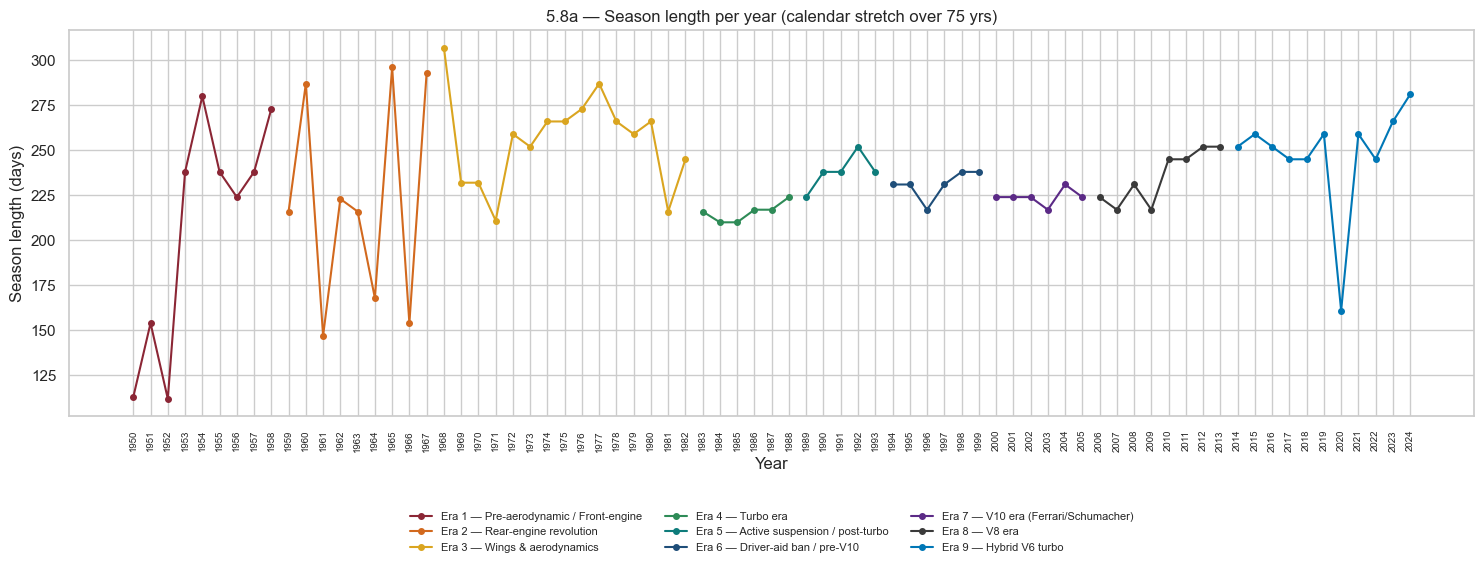

In [63]:
ERA_COLORS = {
    1: '#8B2635', 2: '#D2691E', 3: '#DAA520', 4: '#2E8B57', 5: '#0E7C7B',
    6: '#1F4E79', 7: '#5B2A86', 8: '#3A3A3A', 9: '#0077B6',
}

races['date'] = pd.to_datetime(races['date'])
season_len = (
    races.groupby('year')
         .agg(start_date=('date', 'min'), end_date=('date', 'max'))
         .reset_index()
)
season_len['length_days'] = (
    (season_len['end_date'] - season_len['start_date']).dt.days
)
season_len['era_id'] = season_len['year'].apply(year_to_era)

fig, ax = plt.subplots(figsize=(15, 6))
for era_id, era_group in season_len.groupby('era_id'):
    ax.plot(era_group['year'], era_group['length_days'],
            marker='o', linewidth=1.5, markersize=4,
            color=ERA_COLORS[era_id],
            label=f"Era {era_id} — "
                  f"{eras_df.loc[eras_df.era_id == era_id, 'name_en'].iloc[0]}")

ax.set_xticks(season_len['year'])
ax.set_xticklabels(season_len['year'], rotation=90, fontsize=7)
ax.set_xlabel('Year')
ax.set_ylabel('Season length (days)')
ax.set_title('5.8a — Season length per year (calendar stretch over 75 yrs)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
          ncol=3, fontsize=8, frameon=False)
plt.tight_layout()
show_and_save('5.8a_season_length_yoy.png')


### Chart 5.8b — Average season length grouped by era

Same calculation as 5.8a, then averaged per era. Bar chart, one bar per
era, era-coloured. Annotated with both days and months so the calendar
stretch is legible at a glance (Era 1 ≈ 6 mo, Era 9 ≈ 9 mo).

- **Tables:** `races`
- **Chart:** Bar of mean season length per era, days + months annotation


 era_id                        name_en  year_start  year_end       mean  mean_months       std  n
      1 Pre-aerodynamic / Front-engine        1950      1958 207.777778     6.925926 64.731711  9
      2         Rear-engine revolution        1959      1967 222.222222     7.407407 59.139196  9
      3           Wings & aerodynamics        1968      1982 255.800000     8.526667 25.610266 15
      4                      Turbo era        1983      1988 215.666667     7.188889  5.240865  6
      5 Active suspension / post-turbo        1989      1993 238.000000     7.933333  9.899495  5
      6       Driver-aid ban / pre-V10        1994      1999 231.000000     7.700000  7.668116  6
      7   V10 era (Ferrari/Schumacher)        2000      2005 224.000000     7.466667  4.427189  6
      8                         V8 era        2006      2013 235.375000     7.845833 14.937369  8
      9                Hybrid V6 turbo        2014      2025 247.636364     8.254545 30.663570 11


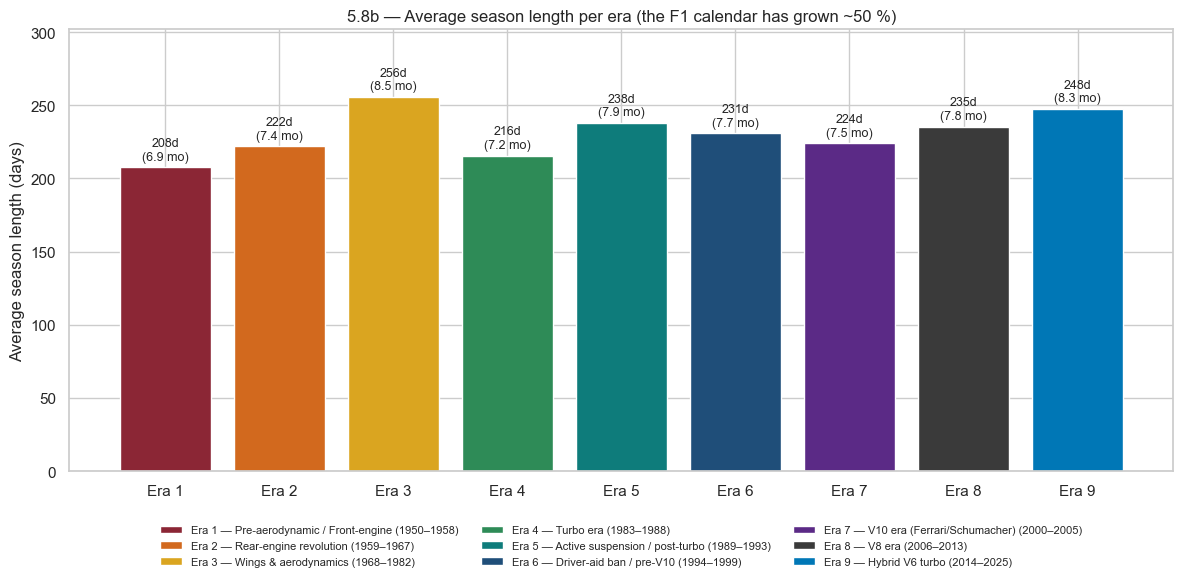

In [64]:
ERA_COLORS = {
    1: '#8B2635', 2: '#D2691E', 3: '#DAA520', 4: '#2E8B57', 5: '#0E7C7B',
    6: '#1F4E79', 7: '#5B2A86', 8: '#3A3A3A', 9: '#0077B6',
}

races['date'] = pd.to_datetime(races['date'])
season_len = (
    races.groupby('year')
         .agg(start_date=('date', 'min'), end_date=('date', 'max'))
         .reset_index()
)
season_len['length_days'] = (
    (season_len['end_date'] - season_len['start_date']).dt.days
)
season_len['era_id'] = season_len['year'].apply(year_to_era)

by_era = (
    season_len.groupby('era_id')['length_days']
              .agg(mean='mean', std='std', n='count')
              .reset_index()
              .merge(eras_df[['era_id', 'name_en', 'year_start', 'year_end']],
                     on='era_id')
)
by_era['mean_months'] = by_era['mean'] / 30.0
by_era['label'] = by_era.apply(
    lambda r: f"Era {int(r.era_id)} — {r.name_en} ({int(r.year_start)}–{int(r.year_end)})",
    axis=1,
)
print(by_era[['era_id', 'name_en', 'year_start', 'year_end',
              'mean', 'mean_months', 'std', 'n']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(by_era['era_id'], by_era['mean'],
              color=[ERA_COLORS[e] for e in by_era['era_id']])
ax.set_xticks(by_era['era_id'])
ax.set_xticklabels([f"Era {e}" for e in by_era['era_id']])
ax.set_ylabel('Average season length (days)')
ax.set_title('5.8b — Average season length per era (the F1 calendar has grown ~50 %)')

for bar, mean, mean_months in zip(bars, by_era['mean'], by_era['mean_months']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            f"{mean:.0f}d\n({mean_months:.1f} mo)",
            ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
legend = [Patch(facecolor=ERA_COLORS[r.era_id], label=r.label)
          for r in by_era.itertuples()]
ax.legend(handles=legend, loc='upper center',
          bbox_to_anchor=(0.5, -0.10), ncol=3, fontsize=8, frameon=False)
ax.set_ylim(0, by_era['mean'].max() * 1.18)
plt.tight_layout()
show_and_save('5.8b_season_length_by_era.png')


### Chart 5.9 — Drivers who finished, per season

How many cars actually saw the chequered flag, on average per race per
season? "Finished" = `status = 'Finished'` OR `status LIKE '+%'` (lapped
but classified) — same condition the Pit Stops chapter uses. Per race we
count finishers, then average across the season. Pairs naturally with
5.10 (grid size) as a reliability/grid-density story.

- **Tables:** `results`, `races`, `status`
- **Chart:** Line, year on x, finishers on y, era-coloured segments


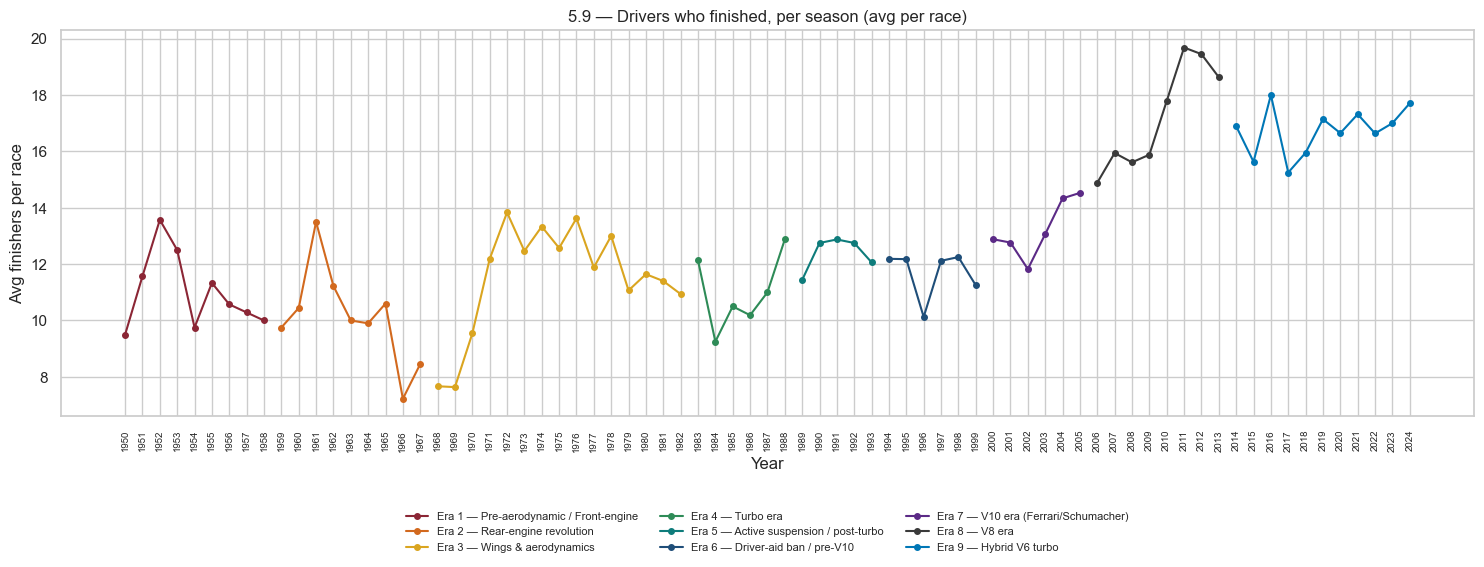

In [65]:
ERA_COLORS = {
    1: '#8B2635', 2: '#D2691E', 3: '#DAA520', 4: '#2E8B57', 5: '#0E7C7B',
    6: '#1F4E79', 7: '#5B2A86', 8: '#3A3A3A', 9: '#0077B6',
}

status = pd.read_csv('excel/status.csv')

results_status = results.merge(status, on='statusId')
finished_mask = (
    (results_status['status'] == 'Finished')
    | (results_status['status'].str.startswith('+'))
)
finished = results_status[finished_mask]

per_race = (
    finished.groupby('raceId').size()
            .reset_index(name='finishers')
            .merge(races[['raceId', 'year']], on='raceId')
)
per_season = (
    per_race.groupby('year')['finishers']
            .mean()
            .reset_index()
)
per_season['era_id'] = per_season['year'].apply(year_to_era)

fig, ax = plt.subplots(figsize=(15, 6))
for era_id, era_group in per_season.groupby('era_id'):
    ax.plot(era_group['year'], era_group['finishers'],
            marker='o', linewidth=1.5, markersize=4,
            color=ERA_COLORS[era_id],
            label=f"Era {era_id} — "
                  f"{eras_df.loc[eras_df.era_id == era_id, 'name_en'].iloc[0]}")

ax.set_xticks(per_season['year'])
ax.set_xticklabels(per_season['year'], rotation=90, fontsize=7)
ax.set_xlabel('Year')
ax.set_ylabel('Avg finishers per race')
ax.set_title('5.9 — Drivers who finished, per season (avg per race)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
          ncol=3, fontsize=8, frameon=False)
plt.tight_layout()
show_and_save('5.9_finishers_per_season.png')


### Chart 5.10 — Average grid size per season

Average number of cars on the starting grid per race, then averaged across
the season. Use `results.grid > 0` to drop pit-lane starts (grid = 0).
Modern F1 has been locked at ~20 cars since 2000; older eras varied
between 15 and 30+.

- **Tables:** `results`, `races`
- **Chart:** Line, year on x, grid size on y, era-coloured segments


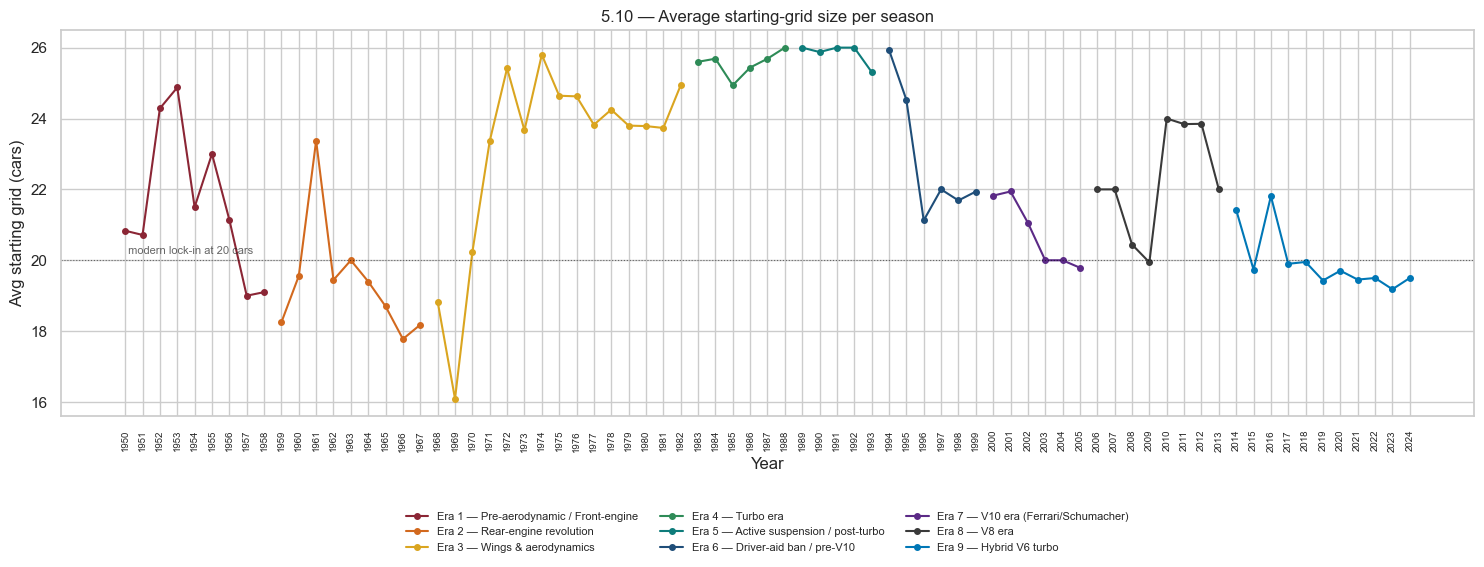

In [66]:
ERA_COLORS = {
    1: '#8B2635', 2: '#D2691E', 3: '#DAA520', 4: '#2E8B57', 5: '#0E7C7B',
    6: '#1F4E79', 7: '#5B2A86', 8: '#3A3A3A', 9: '#0077B6',
}

grid_only = results[results['grid'] > 0]
per_race = (
    grid_only.groupby('raceId').size()
             .reset_index(name='grid_cars')
             .merge(races[['raceId', 'year']], on='raceId')
)
per_season = (
    per_race.groupby('year')['grid_cars']
            .mean()
            .reset_index()
)
per_season['era_id'] = per_season['year'].apply(year_to_era)

fig, ax = plt.subplots(figsize=(15, 6))
for era_id, era_group in per_season.groupby('era_id'):
    ax.plot(era_group['year'], era_group['grid_cars'],
            marker='o', linewidth=1.5, markersize=4,
            color=ERA_COLORS[era_id],
            label=f"Era {era_id} — "
                  f"{eras_df.loc[eras_df.era_id == era_id, 'name_en'].iloc[0]}")

ax.axhline(20, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax.text(per_season['year'].min(), 20.2, ' modern lock-in at 20 cars',
        fontsize=8, alpha=0.7)

ax.set_xticks(per_season['year'])
ax.set_xticklabels(per_season['year'], rotation=90, fontsize=7)
ax.set_xlabel('Year')
ax.set_ylabel('Avg starting grid (cars)')
ax.set_title('5.10 — Average starting-grid size per season')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22),
          ncol=3, fontsize=8, frameon=False)
plt.tight_layout()
show_and_save('5.10_grid_size_per_season.png')


### Chart 5.11 — Sprint races over time

Sprint races joined the F1 calendar in 2021. Count the number of sprint
races per season from `sprint_results.csv` (the authoritative source).
Sanity expectation: 2021 = 3, 2022 = 3, 2023 = 6, 2024 = 6.

- **Tables:** `sprint_results`, `races`
- **Chart:** Bar, 2021–latest year, sprint-race count


 year  n_sprints
 2021          3
 2022          3
 2023          6
 2024          6


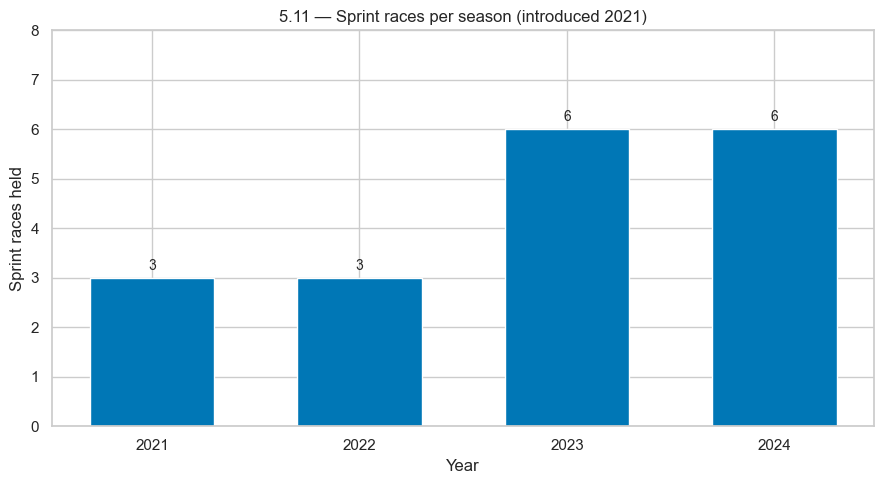

In [67]:
ERA_COLORS = {
    1: '#8B2635', 2: '#D2691E', 3: '#DAA520', 4: '#2E8B57', 5: '#0E7C7B',
    6: '#1F4E79', 7: '#5B2A86', 8: '#3A3A3A', 9: '#0077B6',
}

sprint_results = pd.read_csv('excel/sprint_results.csv')

sprints_per_year = (
    sprint_results.merge(races[['raceId', 'year']], on='raceId')
                  .groupby('year')['raceId']
                  .nunique()
                  .reset_index(name='n_sprints')
                  .sort_values('year')
)
print(sprints_per_year.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(sprints_per_year['year'],
              sprints_per_year['n_sprints'],
              color=ERA_COLORS[9], width=0.6)
ax.set_xticks(sprints_per_year['year'])
ax.set_xticklabels(sprints_per_year['year'])
ax.set_xlabel('Year')
ax.set_ylabel('Sprint races held')
ax.set_title('5.11 — Sprint races per season (introduced 2021)')

for bar, n in zip(bars, sprints_per_year['n_sprints']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            str(int(n)), ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, sprints_per_year['n_sprints'].max() + 2)
plt.tight_layout()
show_and_save('5.11_sprint_races_yoy.png')


---
## Key insights from this notebook

1. **Per-race max points jumped twice** — once in 1991 (9 → 10), once in 2010 (10 → 25). Both jumps mean any "all-time points totals" comparison across eras is misleading; modern drivers accumulate points roughly **2.5× faster** than 80s drivers per win. Chart 5.1 makes this visible at a glance.

2. **Race calendar grew ~4×** since 1950 — from 6 races/season to 24 in 2024 (Chart 5.2). This combined with point inflation means modern career totals dwarf historical ones almost by definition.

3. **Closest title battles** (5.3) include 1964, 1976, 1986, 1994, 2008 — most of the "famous heartbreak" seasons identified in 3.2. Reading both lists side-by-side gives the full storyline.

4. **5.5 distinct-winners ratio** is a good "competitive era" marker. Most years sit at 0.30–0.50; the all-time peaks are 1982 (11 winners in 16 races, 0.69) and 1985.

5. **5.6 is rare** — only a small handful of championships in F1 history were won by a driver with fewer race wins than the runner-up (most famously 1958, 1977, 1979, 1982). Those are seasons where consistency genuinely beat raw speed.
